# 09 — What the business should do, and what it is worth

Eight notebooks produced findings and 08 produced a design. Neither produced a decision, and
a project that stops there hands the business a folder rather than an answer.

This notebook turns the chain into one: what an activation nudge is worth **as a function of
a lift nobody has measured yet**, which input the answer actually hangs on, what running the
test buys over shipping blind or doing nothing, and three tiers of action — including the
things to stop doing, which need no experiment at all.

**The rule that shapes everything below.** 08 produced no effect size, because no randomised
test of this intervention exists. Every euro here is therefore **conditional on a lift**,
swept across a grid that starts at zero and passes through break-even. Nothing below is a
forecast.

Four tags keep that legible, and §8 asserts mechanically that every economic quantity carries
one of them:

| tag | meaning |
|---|---|
| `DATA` | measured on REES46 by an earlier notebook |
| `ASSUMPTION` | a business parameter this dataset cannot observe |
| `SCENARIO` | a lift the experiment has not run yet |
| `DESIGN` | a choice made by 08's design or by this notebook |

Derived quantities carry the **union** of their parents' tags, computed rather than asserted:
the value of an incremental second order is `DATA x ASSUMPTION`, and a euro of annual net
value is `DATA x ASSUMPTION x SCENARIO x DESIGN`. A chain whose output is three-quarters
assumption should say so on its face.


In [1]:
import os, sys, json, math, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from src.plotting import frame, add_title, add_takeaway, save, show_df, thousands

SEED = 42
np.random.seed(SEED)
TABLES_DIR    = os.path.join("outputs", "tables")
FIG_DIR       = os.path.join("outputs", "figures")
PROCESSED_DIR = os.path.join("data", "processed")
for d in (TABLES_DIR, FIG_DIR, PROCESSED_DIR):
    os.makedirs(d, exist_ok=True)

with open(os.path.join("outputs", "handoff_params.json")) as fh:
    handoff = json.load(fh)

DES     = handoff["experiment_design"]
ECON8   = DES["economics"]
LEDGER8 = ECON8["ledger"]
CHURN   = handoff["churn_definition"]
SEG     = handoff["segmentation"]
FEAT    = handoff["features"]
MOD     = handoff["modelling"]
CRX     = handoff["criteo_experiment"]
RET     = handoff["retention_measured"]
COMP    = handoff["compounding_vs_selection"]
BF      = handoff["black_friday_cohort"]
SPAN    = handoff["data_date_range"]

FIGURES, TAKEAWAYS = [], []   # every figure this notebook writes, and its takeaway

print("INHERITED FROM handoff_params.json -- NOT RE-DERIVED")
print("=" * 100)
print(f"  08 design B (RECOMMENDED)  : {ECON8['n_per_arm']:,} per arm, "
      f"{2*ECON8['n_per_arm']:,} total, {ECON8['weeks_to_primary_readout']} weeks to primary readout, "
      f"{ECON8['weeks_to_g2_readout']} to G2")
print(f"  08 trigger / population    : day {DES['trigger']['days_since_first_order']:.0f} after the first order, "
      f"{DES['population']['n_historical_analogue']:,} historical analogues")
print(f"  08 experiment metric       : {DES['metrics']['naming_rule']['experiment_metric']} "
      f"{DES['metrics']['naming_rule']['experiment_window']}, base {DES['population']['base_rate_pct']:.4f}%")
print(f"     NOT 06's                : {DES['metrics']['naming_rule']['nb06_metric']}, "
      f"base {DES['metrics']['naming_rule']['nb06_base_rate_pct']}% -- different population, different window")
print(f"  08 value per 2nd order     : EUR {ECON8['value_per_incremental_second_order_eur']:.4f} "
      f"(order {ECON8['value_components']['margin_on_order']:.4f} + downstream "
      f"{ECON8['value_components']['downstream_1_27x']:.4f} at 02's 1.27x)")
print(f"  08 break-even lift         : {ECON8['break_even_lift_pp']:.4f} pp "
      f"({ECON8['break_even_lift_rel_pct']:.3f}% relative); MDE {ECON8['mde_pp']:.2f} pp = "
      f"{ECON8['mde_over_breakeven']:.2f}x break-even")
print(f"  03 churn rule              : {CHURN['certified_threshold_days']}d, recall "
      f"{CHURN['validation']['specB']['recall_pct']}%, region {CHURN['certified_region_days']} -- NOT the trigger")
print(f"  06 shipped model           : AP {MOD['shipped_model']['test_AP']} vs "
      f"{MOD['baselines']['BASE  prevalence only']['AP']} base, ROC {MOD['shipped_model']['test_ROC_AUC']}")
print(f"  07 risk targeting          : "
      f"{CRX['policy_comparison']['policies'][2]['pct_of_total_effect']:.1f}% of the achievable effect "
      f"vs random 50%'s {CRX['policy_comparison']['policies'][5]['pct_of_total_effect']:.1f}%")
print(f"  data span                  : {SPAN['min']} -> {SPAN['max']} ({SPAN['span_days']} days)")


INHERITED FROM handoff_params.json -- NOT RE-DERIVED
  08 design B (RECOMMENDED)  : 40,719 per arm, 81,438 total, 26 weeks to primary readout, 33 to G2
  08 trigger / population    : day 14 after the first order, 74,548 historical analogues
  08 experiment metric       : repeat_30d_from_trigger (t0 + 14d, t0 + 44d], base 10.2484%
     NOT 06's                : repeat_purchase_30d, base 13.73% -- different population, different window
  08 value per 2nd order     : EUR 12.7570 (order 12.2659 + downstream 0.4910 at 02's 1.27x)
  08 break-even lift         : 0.3919 pp (3.824% relative); MDE 1.00 pp = 2.55x break-even
  03 churn rule              : 42.2d, recall 53.09%, region [30.0, 45.0] -- NOT the trigger
  06 shipped model           : AP 0.1809 vs 0.1165 base, ROC 0.6278
  07 risk targeting          : 1.0% of the achievable effect vs random 50%'s 49.8%
  data span                  : 2019-10-01 00:00:00 -> 2020-02-29 23:59:59 (151 days)


## 1. Impact is conditional, not predicted

### 1A — The constraints this notebook inherits

08 recorded nine binding rules for 09 and the notebooks before it recorded more. They are not
style guidance: each one names a specific way this chapter could be written wrong, and most
of them were learned by an earlier notebook writing it wrong first. Every one is restated
below verbatim from the handoff, with the section that discharges it.


In [2]:
RULES9 = DES["binding_rules_for_09"]
assert len(RULES9) == 9, len(RULES9)
DISCHARGED = [
    "S3 -- the lift is a free axis; no line in any table is a forecast",
    "S3B -- grid {0, break-even, 0.50, 0.75, 1.00, 1.50} pp; the crossing is drawn",
    "S3A -- reach is the trigger flow (enrolments/day x 365.25); S6 DO-NOW 1 and 2",
    "S2 -- V registered at EUR 12.757 with the 1.27x term; asserted against 08 in S8",
    "S2 -- four-tag ledger and figure; S4 prices both assumptions",
    "S3C -- the rescheduling scenario is a line on the impact figure, not a footnote",
    "S3A -- 695.36/day, the October-excluded rate, asserted in S8",
    "S2/S3 -- the chain runs on 10.248%; S8 asserts 13.73% never enters it",
    "S1B/S5 -- design B, 40,719 per arm and 26 weeks, taken from the handoff",
]
assert len(DISCHARGED) == len(RULES9)

OTHER = [
    ("03", CHURN["addressable_population"]["binding_rule_for_08_09"],
     "S6 DO-NOW 1 -- true at-risk = correctly_flagged / recall, never flagged / recall"),
    ("04", SEG["stability"]["binding_rule_for_08_09"],
     "S6 DO-NOW 4 -- re-score at send time; a stored label is not an attribute"),
    ("04", SEG["binding_constraint_from_03"]["structural_point"],
     "S6 DO-NOW 1 -- half the at-risk base sits in cells that look healthy"),
    ("06", MOD["binding_rules_for_07_08_09"][0],
     "S3 -- no line in the chain assumes a propensity model works; none is used"),
    ("06", MOD["binding_rules_for_07_08_09"][2],
     "S6 STOP 1 -- propensity is not uplift; the score is not a targeting rule"),
    ("07", CRX["carry_back_to_rees46"]["what_does_not_transfer"][0],
     "S8 -- asserted mechanically: no Criteo magnitude enters any calculation"),
    ("02", BF["interpretation_limit"],
     "S6 STOP 3 -- the Black Friday gap is a reason to investigate, not to price"),
    ("00", handoff["known_limitations"][0],
     "S7 -- stated as the first thing this project cannot tell the business"),
]

CONS = [dict(source="08", constraint=r, what_09_does=d) for r, d in zip(RULES9, DISCHARGED)]
CONS += [dict(source=s, constraint=c, what_09_does=d) for s, c, d in OTHER]
CONS = pd.DataFrame(CONS)
CONS["constraint"] = CONS["constraint"].str.replace(r"\s+", " ", regex=True)
show_df(CONS.assign(constraint=CONS.constraint.str.slice(0, 96) + "..."),
        "nb09_inherited_constraints", max_rows=20)
CONS.to_csv(os.path.join(TABLES_DIR, "nb09_inherited_constraints.csv"), index=False)
print()
print(f"  {len(CONS)} inherited constraints, {len(RULES9)} of them 08's binding rules for this notebook.")
print(f"  Full text in outputs/tables/nb09_inherited_constraints.csv.")


   source                                         constraint                                       what_09_does
0      08  08 PRODUCED NO EFFECT SIZE. 09's ROI chain mus...  S3 -- the lift is a free axis; no line in any ...
1      08  If 09 models a scenario, it must sweep lift as...  S3B -- grid {0, break-even, 0.50, 0.75, 1.00, ...
2      08  Reach comes from the TRIGGER, not from the chu...  S3A -- reach is the trigger flow (enrolments/d...
3      08  Value per incremental second order is EUR 12.7...  S2 -- V registered at EUR 12.757 with the 1.27...
4      08  Contact cost and contribution margin are ASSUM...  S2 -- four-tag ledger and figure; S4 prices bo...
5      08  The pull-forward risk is unresolved and unreso...  S3C -- the rescheduling scenario is a line on ...
6      08  Every duration in 09 must use the October-excl...  S3A -- 695.36/day, the October-excluded rate, ...
7      08  THE EXPERIMENT'S METRIC IS NOT 06's. repeat_30...  S2/S3 -- the chain runs on 10.248%; S8 ass

### 1B — A two-user correction to 08's prose, before anything is built on it

08's §6J markdown and its closing summary say **40,721 per arm** and 81,442 users. Its
executed cell, `nb08_design_comparison.csv` and the handoff all say **40,719** and 81,438.
The prose is wrong and the cause is recoverable from the git history rather than guessed at.

The addendum commit (`7ac9385`) computed 40,721. The determinism commit (`05a483d`) then fixed
the orders sort key — `(user_id, order_ts, user_session)`, because a sort on the first two
alone is not unique and five user+timestamp pairs carry two orders in different sessions — and
re-ran the notebook. The second-order AOV moved from `40.88553389006` to `40.88647032592833`,
which moved break-even from 0.391951 pp to 0.391942 pp, which moved the decision-powered
sample size two users. The executed outputs and the handoff moved with it; four markdown cells
did not.

09 uses the handoff, because the handoff is the artefact 08's own self-verification checked.
The consequence of the difference is €0.10 of contact spend and nothing else — which is
exactly why it is recorded here rather than silently absorbed: the number is immaterial, the
habit of leaving a stale figure in prose is not.


In [3]:
CORRECTIONS = pd.DataFrame([dict(
    item="design B sample size quoted in 08's markdown",
    stale_value="40,721 per arm / 81,442 total",
    correct_value=f"{ECON8['n_per_arm']:,} per arm / {2*ECON8['n_per_arm']:,} total",
    source_of_truth="handoff_params.json -> experiment_design.economics.n_per_arm, nb08_design_comparison.csv",
    cause=("05a483d fixed the orders sort key; aov_second_order moved 40.88553389006 -> 40.88647032592833, "
           "break-even 0.391951 -> 0.391942 pp, n 40,721 -> 40,719. Executed cells and the handoff "
           "re-ran; four markdown cells in 08 did not."),
    material_consequence="EUR 0.10 of contact spend; no figure, table or decision in 08 or 09 changes",
    action="09 quotes 40,719 / 26 weeks throughout, per 08's own binding rule",
)])
show_df(CORRECTIONS, "nb09_corrections", max_rows=5)

za, zb = 1.959963984540054, 0.8416212335729143   # z_{0.975}, z_{0.80}

def _n_decision(p0, delta, be):
    """08 S6H: n per arm for 80% power that the 95% CI lower bound clears `be` at `delta`."""
    p1 = p0 + delta
    se_required = (delta - be) / (za + zb)
    return (p0 * (1 - p0) + p1 * (1 - p1)) / se_required ** 2
P0_CHK = LEDGER8["base_rate"]["value"]      # full precision, not the 4-dp figure in population
for aov, expect in [(40.88553389006, 40721), (40.88647032592833, 40719)]:
    v = 0.30 * aov * (1 + LEDGER8["downstream_uplift"]["value"])
    n = math.ceil(_n_decision(P0_CHK, 0.01, 0.05 / v))
    print(f"  AOV {aov:.11f} -> V {v:.6f} -> break-even {100*0.05/v:.6f} pp -> n {n:,}   "
          f"{'(08 prose)' if expect == 40721 else '(08 executed + handoff + 09)'}")
    assert n == expect, (n, expect)


                                           item                    stale_value                  correct_value  \
0  design B sample size quoted in 08's markdown  40,721 per arm / 81,442 total  40,719 per arm / 81,438 total   

                                     source_of_truth                                              cause                               material_consequence  \
0  handoff_params.json -> experiment_design.econo...  05a483d fixed the orders sort key; aov_second_...  EUR 0.10 of contact spend; no figure, table or...   

                                              action  
0  09 quotes 40,719 / 26 weeks throughout, per 08...  
  AOV 40.88553389006 -> V 12.756683 -> break-even 0.391951 pp -> n 40,721   (08 prose)
  AOV 40.88647032593 -> V 12.756975 -> break-even 0.391942 pp -> n 40,719   (08 executed + handoff + 09)


## 2. The economic inputs, with four tags

Eight inputs come straight from 08's ledger and are asserted equal to it, value and tag, in
§8. Four more are choices this notebook makes and are tagged `DESIGN`, and the lift itself is
the `SCENARIO` axis.

The tag is the whole point of this section. Three of the eight inherited inputs are
measurements of this retailer and cannot be argued with; two are business parameters that
REES46 does not contain at all — the data carries price, never cost — and §4 shows that one
of those two decides the answer.


In [4]:
TAGS = ("DATA", "ASSUMPTION", "SCENARIO", "DESIGN")
INPUTS, DERIVED = {}, {}

def register(key, value, tag, source, unit="", note=""):
    assert tag in TAGS, tag
    INPUTS[key] = dict(key=key, value=float(value), unit=unit, tag=tag, source=source, note=note)
    return float(value)

def derive(key, value, parents, formula, unit=""):
    tags = set()
    for p in parents:
        tags |= set((INPUTS[p]["tag"] if p in INPUTS else DERIVED[p]["tag"]).split(" x "))
    tag = " x ".join(sorted(tags, key=TAGS.index))
    DERIVED[key] = dict(key=key, value=float(value), unit=unit, tag=tag,
                        parents=", ".join(parents), formula=formula)
    return float(value)

# ---- the eight inherited from 08, values and tags unchanged ---------------------------
# the handoff carries value/tag/source; unit and note live in 08's own table, so take them there
L8 = pd.read_csv(os.path.join(TABLES_DIR, "nb08_economics_ledger.csv")).set_index("key")
for k, v in LEDGER8.items():
    assert abs(float(L8.loc[k, "value"]) - v["value"]) < 1e-12 and L8.loc[k, "tag"] == v["tag"]
    register(k, v["value"], v["tag"], f"08 ledger <- {v['source']}",
             str(L8.loc[k, "unit"]), str(L8.loc[k, "note"]))

P0        = INPUTS["base_rate"]["value"]
AOV2      = INPUTS["aov_second_order"]["value"]
DOWNSTREAM = INPUTS["downstream_uplift"]["value"]
INFLOW_DAY = INPUTS["first_buyer_inflow_per_day"]["value"]
SURVIVAL  = INPUTS["trigger_survival_share"]["value"]
CONTACT   = INPUTS["contact_cost"]["value"]
MARGIN    = INPUTS["contribution_margin"]["value"]
DISCOUNT  = INPUTS["discount_rate"]["value"]

# ---- this notebook's own choices ------------------------------------------------------
HOLDBACK = register("holdback_share", 0.10, "DESIGN",
                    "08 T5 -- a permanent holdback is the handling for novelty/decay", "share",
                    "10% of enrolments are never contacted, so the effect stays measurable after ship")
N_PER_ARM = register("n_per_arm_design_B", ECON8["n_per_arm"], "DESIGN",
                     "08 economics.n_per_arm -- the decision-powered design", "users/arm",
                     "NOT the superseded 15,058; that design ships 39.9% of the time at the same true effect")
WEEKS_READOUT = register("weeks_to_primary_readout", ECON8["weeks_to_primary_readout"], "DESIGN",
                         "08 economics.weeks_to_primary_readout", "weeks",
                         "2 ramp + 19 enrolment + 5 outcome; G2 pull-forward at 33 weeks")
HORIZON_WEEKS = register("evaluation_horizon_weeks", 104.0, "DESIGN",
                         "this notebook -- two years from the decision point", "weeks",
                         "long enough that a 26-week delay is priced rather than ignored")
COST_OF_CAPITAL = register("cost_of_capital", 0.0, "ASSUMPTION",
                           "business input -- no time-discounting applied", "share/yr",
                           "at these magnitudes a 5% rate moves the 2-year figures by under EUR 900")

# ---- the SCENARIO axis: the two quantities the experiment has not measured -------------
TARGET = register("true_lift_at_target", 0.010, "SCENARIO",
                  "08 economics.mde_pp -- the design target, swept across a grid in S3B", "share",
                  "NOT a forecast and not an estimate: the value the tornado in S4 holds while the "
                  "assumptions move. The grid that contains it starts at zero.")
NEW_DEMAND_SHARE = register("new_demand_share", 1.0, "SCENARIO",
                            "S3C -- the share of a measured 30-day lift that is new demand", "share",
                            "1.0 is the optimistic end. Unresolved until G2 at 33 weeks; S3C sweeps it to 0.")

LIFT_GRID = [0.0, None, 0.005, 0.0075, TARGET, 0.015]     # None is replaced by break-even below
LIFT_LABELS = ["nothing happens", "break-even", "half a point", "three quarters",
               "08's target", "a large effect"]

# ---- derived --------------------------------------------------------------------------
V_ORDER = derive("value_margin_on_order", MARGIN * AOV2, ["contribution_margin", "aov_second_order"],
                 "margin x AOV2", "EUR")
V_DOWN  = derive("value_downstream_127x", MARGIN * AOV2 * DOWNSTREAM,
                 ["contribution_margin", "aov_second_order", "downstream_uplift"],
                 "margin x AOV2 x downstream_uplift", "EUR")
V_TOTAL = derive("value_per_incremental_2nd_order", V_ORDER + V_DOWN,
                 ["value_margin_on_order", "value_downstream_127x"], "V_order + V_downstream", "EUR")
BE      = derive("break_even_lift", CONTACT / V_TOTAL, ["contact_cost", "value_per_incremental_2nd_order"],
                 "c / V", "share")
ENROL_DAY = derive("enrolments_per_day", INFLOW_DAY * SURVIVAL,
                   ["first_buyer_inflow_per_day", "trigger_survival_share"], "inflow x survival", "users/day")
ENROL_YEAR = derive("enrolments_per_year", ENROL_DAY * 365.25, ["enrolments_per_day"],
                    "enrolments/day x 365.25", "users/yr")
TREATED_YEAR = derive("treated_per_year", ENROL_YEAR * (1 - HOLDBACK), ["enrolments_per_year", "holdback_share"],
                      "enrolments/yr x (1 - holdback)", "users/yr")
NET_AT_TARGET = derive("net_value_per_year_at_target",
                       ENROL_YEAR * (1 - HOLDBACK) * (TARGET * V_TOTAL - CONTACT),
                       ["treated_per_year", "true_lift_at_target", "value_per_incremental_2nd_order",
                        "contact_cost"],
                       "treated/yr x (lift x V - c)", "EUR/yr")

LIFT_GRID[1] = BE

LED = pd.DataFrame(list(INPUTS.values()))[["key", "value", "unit", "tag", "source", "note"]]
DRV = pd.DataFrame(list(DERIVED.values()))[["key", "value", "unit", "tag", "formula", "parents"]]
show_df(LED, "nb09_economic_inputs", max_rows=20)
print()
show_df(DRV, "nb09_derived_quantities", max_rows=20)
print()
for t in TAGS:
    print(f"  {t:<10} inputs: {(LED.tag == t).sum()}")
print(f"  derived tags : {sorted(DRV.tag.unique().tolist(), key=len)}")
print()
print(f"  V = EUR {V_TOTAL:.4f}  (order {V_ORDER:.4f} + downstream {V_DOWN:.4f} at 02's 1.27x residual)")
print(f"  break-even lift = c/V = {100*BE:.4f} pp = {100*BE/P0:.3f}% relative, against a {100*P0:.3f}% base rate")
print(f"  REJECTED: the naive 2.00x downstream term would give V = EUR "
      f"{ECON8['rejected_naive_value_eur']:.4f} and understate the bar {ECON8['naive_overstates_downstream_by']:.1f}x "
      f"on the downstream component alone")


                           key         value         unit         tag                                             source  \
0                    base_rate      0.102484        share        DATA  08 ledger <- 05 features.parquet, day-14 trigg...   
1             aov_second_order     40.886470          EUR        DATA  08 ledger <- 05 orders.parquet, second orders,...   
2            downstream_uplift      0.040032        share        DATA  08 ledger <- 02 S0B compounding-vs-selection, ...   
3   first_buyer_inflow_per_day    695.363636    users/day        DATA  08 ledger <- 05 features.parquet, first-order ...   
4       trigger_survival_share      0.916792        share        DATA  08 ledger <- this notebook S3C trigger sweep, ...   
5                 contact_cost      0.050000  EUR/contact  ASSUMPTION  08 ledger <- business input -- transactional e...   
6          contribution_margin      0.300000        share  ASSUMPTION  08 ledger <- business input -- cosmetics e-com...   
7       

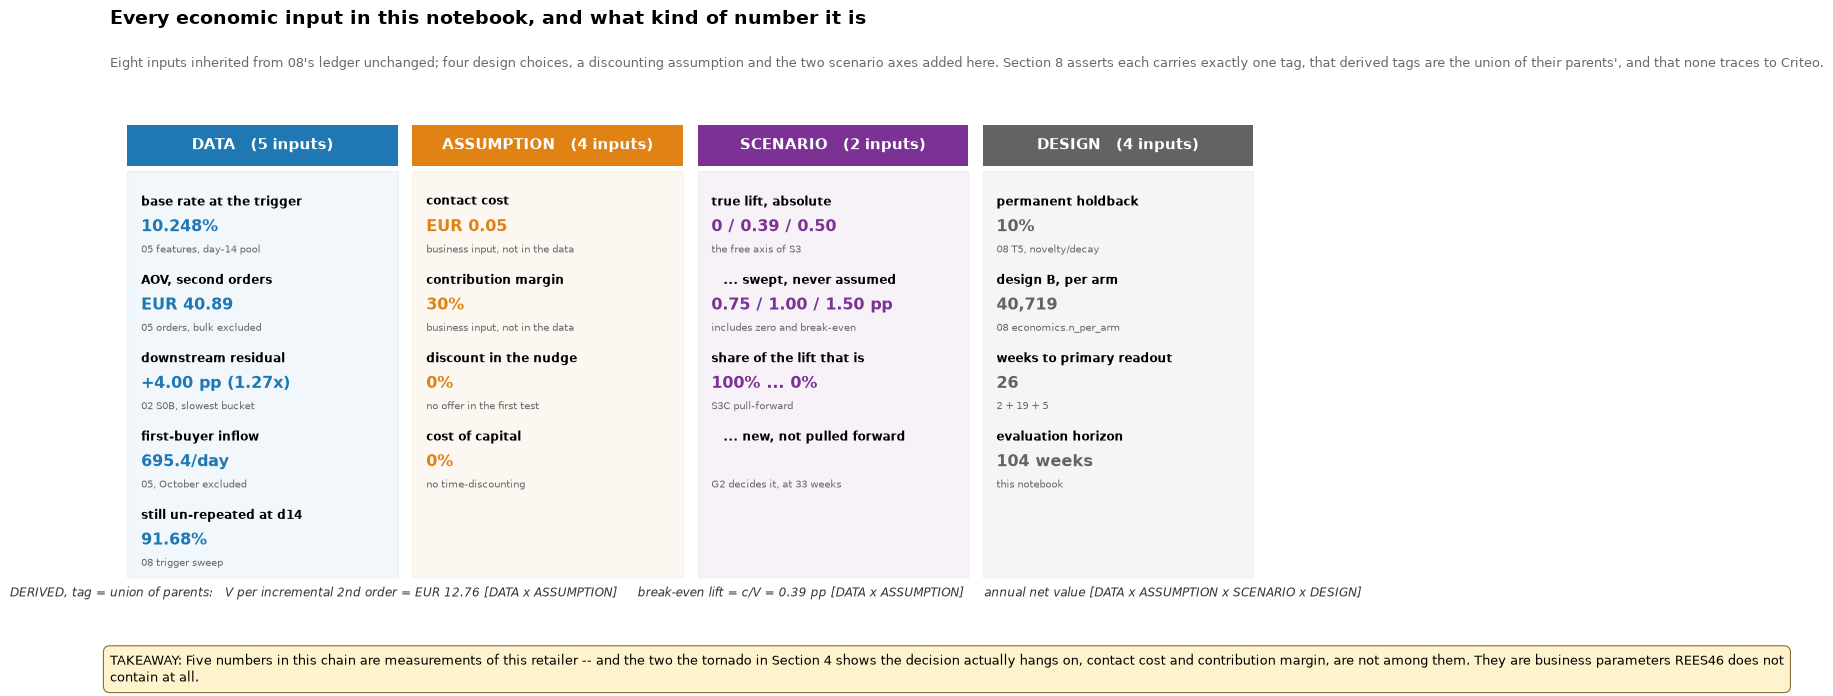

In [5]:
fig = plt.figure(figsize=(12.0, 7.2))
ax = fig.add_axes([0.02, 0.14, 0.96, 0.68]); ax.set_axis_off()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

PALETTE = {"DATA": "#1f78b4", "ASSUMPTION": "#e08214", "SCENARIO": "#7b3294", "DESIGN": "#636363"}
CONTENT = {
    "DATA": [("base rate at the trigger", f"{100*P0:.3f}%", "05 features, day-14 pool"),
             ("AOV, second orders", f"EUR {AOV2:.2f}", "05 orders, bulk excluded"),
             ("downstream residual", f"+{100*DOWNSTREAM:.2f} pp (1.27x)", "02 S0B, slowest bucket"),
             ("first-buyer inflow", f"{INFLOW_DAY:.1f}/day", "05, October excluded"),
             ("still un-repeated at d14", f"{100*SURVIVAL:.2f}%", "08 trigger sweep")],
    "ASSUMPTION": [("contact cost", f"EUR {CONTACT:.2f}", "business input, not in the data"),
                   ("contribution margin", f"{MARGIN:.0%}", "business input, not in the data"),
                   ("discount in the nudge", f"{DISCOUNT:.0%}", "no offer in the first test"),
                   ("cost of capital", f"{COST_OF_CAPITAL:.0%}", "no time-discounting")],
    "SCENARIO": [("true lift, absolute", "0 / 0.39 / 0.50", "the free axis of S3"),
                 ("   ... swept, never assumed", "0.75 / 1.00 / 1.50 pp", "includes zero and break-even"),
                 ("share of the lift that is", "100% ... 0%", "S3C pull-forward"),
                 ("   ... new, not pulled forward", "", "G2 decides it, at 33 weeks")],
    "DESIGN": [("permanent holdback", f"{HOLDBACK:.0%}", "08 T5, novelty/decay"),
               ("design B, per arm", f"{int(N_PER_ARM):,}", "08 economics.n_per_arm"),
               ("weeks to primary readout", f"{int(WEEKS_READOUT)}", "2 + 19 + 5"),
               ("evaluation horizon", f"{int(HORIZON_WEEKS)} weeks", "this notebook")],
}
for i, tag in enumerate(TAGS):
    x0 = 0.015 + i * 0.2475
    col = PALETTE[tag]
    n_in = int((LED.tag == tag).sum())
    ax.add_patch(Rectangle((x0, 0.90), 0.235, 0.085, facecolor=col, edgecolor="none"))
    ax.text(x0 + 0.1175, 0.9425, f"{tag}   ({n_in} input{'s' if n_in != 1 else ''})",
            ha="center", va="center", fontsize=10.5, fontweight="bold", color="white")
    ax.add_patch(Rectangle((x0, 0.06), 0.235, 0.83, facecolor=col, edgecolor=col, alpha=0.06, linewidth=1.0))
    for j, (k, v, src) in enumerate(CONTENT[tag]):
        y = 0.84 - j * 0.160
        ax.text(x0 + 0.012, y, k, fontsize=8.6, fontweight="bold", va="top")
        ax.text(x0 + 0.012, y - 0.048, v, fontsize=11.5, color=col, fontweight="bold", va="top")
        ax.text(x0 + 0.012, y - 0.100, src, fontsize=7.4, color="dimgray", va="top")

ax.text(0.5, 0.015,
        f"DERIVED, tag = union of parents:   V per incremental 2nd order = EUR {V_TOTAL:.2f} "
        f"[DATA x ASSUMPTION]     break-even lift = c/V = {100*BE:.2f} pp [DATA x ASSUMPTION]     "
        f"annual net value [DATA x ASSUMPTION x SCENARIO x DESIGN]",
        ha="center", va="bottom", fontsize=8.4, style="italic", color="#333333")

add_title(fig, "Every economic input in this notebook, and what kind of number it is",
          "Eight inputs inherited from 08's ledger unchanged; four design choices, a discounting assumption "
          "and the two scenario axes added here. Section 8 asserts each carries exactly one tag, that derived "
          "tags are the union of their parents', and that none traces to Criteo.")
add_takeaway(fig, "Five numbers in this chain are measurements of this retailer -- and the two the tornado in "
                  "Section 4 shows the decision actually hangs on, contact cost and contribution margin, are "
                  "not among them. They are business parameters REES46 does not contain at all.")
save(fig, "nb09_economic_inputs"); FIGURES.append("nb09_economic_inputs")
TAKEAWAYS.append("nb09_economic_inputs"); plt.show()


## 3. The conditional impact chain

### 3A — Reach, and where it does *not* come from

The reach of this campaign is a **flow**, not a stock. 08's trigger fires 14 days after a
first order, so the addressable population is the rate at which first-time buyers arrive
times the share still un-repeated at day 14 — not a count of users sitting in a list today.

That distinction is 03's binding rule for 08 and 09, and it is the single most common way a
retention business case is inflated. 03 flagged 36,495 users under the certified 42.2-day
rule. Sizing on that number is wrong twice over: recall is 53.09%, so the flagged set misses
28,986 genuinely at-risk users, and 3,694 of those it does flag are false positives. The
arithmetic that recovers the true base is `correctly_flagged / recall`, never
`flagged / recall` — 04 §9A had to withdraw the second version after applying it inside cells
where it was anti-correlated with the truth.

Neither number enters the chain below, because the trigger does not use the churn rule at all.


In [6]:
AP = CHURN["addressable_population"]
true_at_risk = AP["n_correctly_flagged"] / (AP["recall_pct"] / 100.0)
wrong_at_risk = AP["n_flagged"] / (AP["recall_pct"] / 100.0)

print("THE STOCK ARITHMETIC 09 DOES NOT USE (03's binding rule, restated so it is legible)")
print("=" * 100)
print(f"  flagged by the 42.2d rule            : {AP['n_flagged']:,}")
print(f"  of them correctly flagged            : {AP['n_correctly_flagged']:,}  "
      f"({AP['n_flagged'] - AP['n_correctly_flagged']:,} false positives)")
print(f"  recall                               : {AP['recall_pct']}%")
print(f"  TRUE at-risk base = correct / recall : {true_at_risk:,.0f}   (03 records {AP['n_true_at_risk']:,})")
print(f"  the wrong version, flagged / recall  : {wrong_at_risk:,.0f}   "
      f"-- double-counts the false positives by {wrong_at_risk - true_at_risk:,.0f}")
print(f"  sizing on the flagged count alone    : {AP['n_flagged']:,} = "
      f"{100*AP['n_flagged']/true_at_risk - 100:+.1f}% against the true base")
print()
print("THE FLOW ARITHMETIC 09 USES")
print("=" * 100)
print(f"  [DATA]   first-time-buyer inflow      : {INFLOW_DAY:,.2f} users/day   "
      f"(2019-11-01 onward; October is left-censored and would read 726.7/day, 4.5% high)")
print(f"  [DATA]   x still un-repeated at day 14: {100*SURVIVAL:.2f}%")
print(f"           = ENROLMENTS                 : {ENROL_DAY:,.2f}/day = {ENROL_YEAR:,.0f}/year")
print(f"  [DESIGN] x (1 - {HOLDBACK:.0%} permanent holdback) : {TREATED_YEAR:,.0f} contacted/year")
print(f"           the holdback is not overhead: it is what keeps the effect measurable after ship (08 T5)")
print()
print(f"  For scale: design B enrols {2*int(N_PER_ARM):,} users, which is "
      f"{200*int(N_PER_ARM)/ENROL_YEAR:.0f}% of one year of this flow, and consumes "
      f"{100*2*int(N_PER_ARM)/(ENROL_YEAR*WEEKS_READOUT/52):.0f}% of the enrolments available during its "
      f"{int(WEEKS_READOUT)} weeks.")


THE STOCK ARITHMETIC 09 DOES NOT USE (03's binding rule, restated so it is legible)
  flagged by the 42.2d rule            : 36,495
  of them correctly flagged            : 32,801  (3,694 false positives)
  recall                               : 53.09%
  TRUE at-risk base = correct / recall : 61,784   (03 records 61,787)
  the wrong version, flagged / recall  : 68,742   -- double-counts the false positives by 6,958
  sizing on the flagged count alone    : 36,495 = -40.9% against the true base

THE FLOW ARITHMETIC 09 USES
  [DATA]   first-time-buyer inflow      : 695.36 users/day   (2019-11-01 onward; October is left-censored and would read 726.7/day, 4.5% high)
  [DATA]   x still un-repeated at day 14: 91.68%
           = ENROLMENTS                 : 637.50/day = 232,848/year
  [DESIGN] x (1 - 10% permanent holdback) : 209,563 contacted/year
           the holdback is not overhead: it is what keeps the effect measurable after ship (08 T5)

  For scale: design B enrols 81,438 users, whi

### 3B — The chain, priced across a lift the experiment has not measured

Each line carries its tag. The only line that changes between scenarios is the lift, and the
lift is the one line no observational analysis in this project can supply — which is the whole
argument for running the test rather than modelling harder.

```
  enrolments/yr            [DATA]       inflow x day-14 survival x 365.25
  x (1 - holdback)         [DESIGN]     90% of enrolments are contacted
  x lift                   [SCENARIO]   0 ... 1.5 pp, the free axis
  x V per incremental order[DATA x ASSUMPTION]   margin x AOV2 x (1 + 1.27x residual)
  - contact cost x treated [ASSUMPTION] EUR 0.05 on every contact, converting or not
  = NET ANNUAL VALUE
```

Two properties of this shape are worth stating before the numbers. Cost is **linear in reach
and independent of the lift** — the campaign pays for every contact whether or not it works —
so the whole chain is a straight line through `(break-even, 0)`. And the holdback costs value
in exact proportion to the lift: at a true 1.00 pp effect it forgoes about €3,000 a year, which
is the price of continuing to know whether the campaign works.


In [7]:
def chain(delta, treated=None, contact=None, v=None):
    treated = TREATED_YEAR if treated is None else treated
    contact = CONTACT if contact is None else contact
    v = V_TOTAL if v is None else v
    inc = treated * delta
    gross = inc * v
    cost = treated * contact
    return dict(inc_orders=inc, gross=gross, cost=cost, net=gross - cost,
                roi=(gross - cost) / cost if cost else np.nan)

IMPACT = []
for d, lab in zip(LIFT_GRID, LIFT_LABELS):
    c = chain(d)
    IMPACT.append(dict(
        scenario=lab,
        lift_pp=round(100 * d, 4),
        lift_rel_pct=round(100 * d / P0, 2),
        inc_2nd_orders_per_yr=round(c["inc_orders"], 1),
        gross_eur=round(c["gross"]),
        contact_cost_eur=round(c["cost"]),
        net_eur=round(c["net"]),
        roi=round(c["roi"], 3),
        net_per_1k_contacted_eur=round(1000 * c["net"] / TREATED_YEAR, 2),
        holdback_forgone_eur=round(ENROL_YEAR * HOLDBACK * d * V_TOTAL),
        verdict=("loses money" if d < BE - 1e-12 else "break-even" if abs(d - BE) < 1e-12 else "pays"),
    ))
IMPACT = pd.DataFrame(IMPACT)
show_df(IMPACT, "nb09_conditional_impact", max_rows=10)
print()
print(f"  Reading: at a true lift of {100*LIFT_GRID[4]:.2f} pp -- 08's design target, and 2.55x the "
      f"break-even line --")
print(f"  the campaign generates {IMPACT.iloc[4].inc_2nd_orders_per_yr:,.0f} incremental second orders a year, "
      f"EUR {IMPACT.iloc[4].gross_eur:,.0f} gross,")
print(f"  EUR {IMPACT.iloc[4].net_eur:,.0f} net of EUR {IMPACT.iloc[4].contact_cost_eur:,.0f} of contact spend, "
      f"an ROI of {IMPACT.iloc[4].roi:.2f}x.")
print()
print("  NONE OF THESE ROWS IS A FORECAST. The lift column is the SCENARIO axis; the experiment has")
print("  not run. The row that matters most is the first: at a true zero the campaign costs")
print(f"  EUR {abs(IMPACT.iloc[0].net_eur):,.0f} a year and returns nothing, and no analysis in this project can")
print("  rule that row out.")


          scenario  lift_pp  lift_rel_pct  inc_2nd_orders_per_yr  gross_eur  contact_cost_eur  net_eur    roi  net_per_1k_contacted_eur  holdback_forgone_eur  \
0  nothing happens   0.0000          0.00                    0.0          0             10478   -10478 -1.000                    -50.00                     0   
1       break-even   0.3919          3.82                  821.4      10478             10478        0  0.000                      0.00                  1164   
2     half a point   0.5000          4.88                 1047.8      13367             10478     2889  0.276                     13.78                  1485   
3   three quarters   0.7500          7.32                 1571.7      20050             10478     9572  0.914                     45.68                  2228   
4      08's target   1.0000          9.76                 2095.6      26734             10478    16256  1.551                     77.57                  2970   
5   a large effect   1.5000       

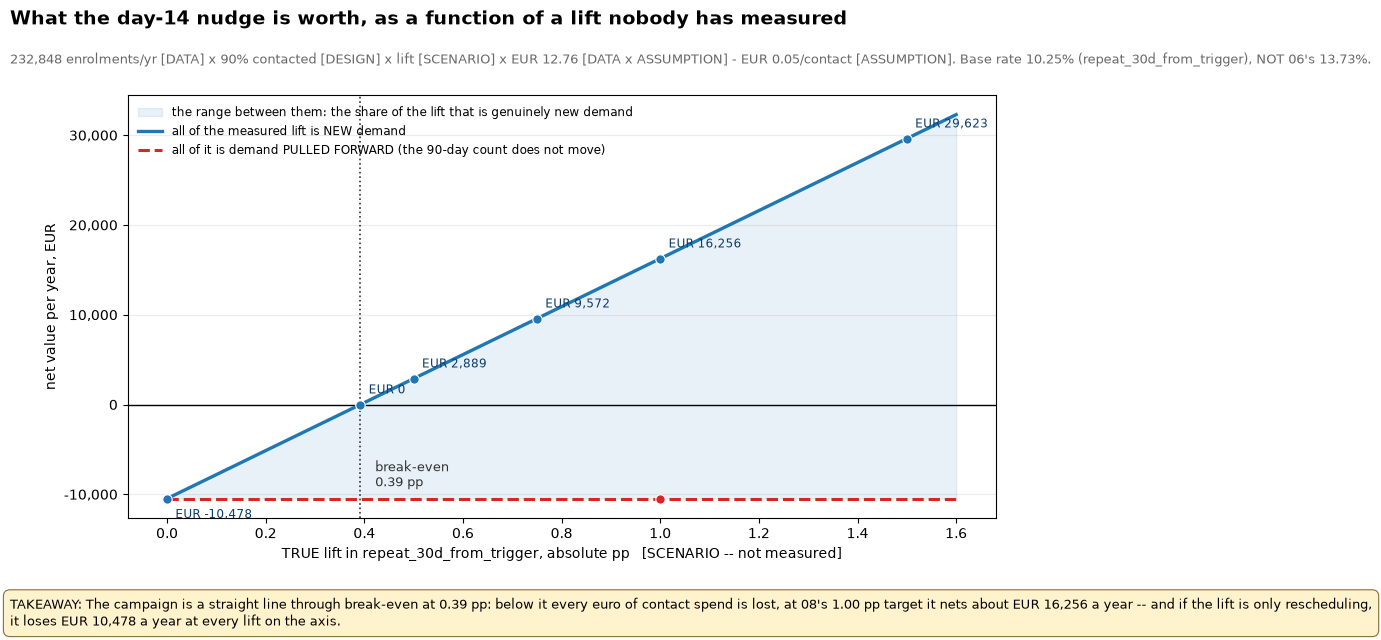

In [8]:
xs = np.linspace(0.0, 0.016, 400)
created = TREATED_YEAR * (xs * V_TOTAL - CONTACT)
pulled  = np.full_like(xs, -TREATED_YEAR * CONTACT)

fig, ax = frame(figsize=(11.2, 6.6))
ax.fill_between(100 * xs, pulled, created, color="#1f78b4", alpha=0.10, zorder=1,
                label="the range between them: the share of the lift that is genuinely new demand")
ax.plot(100 * xs, created, color="#1f78b4", lw=2.4, zorder=3,
        label="all of the measured lift is NEW demand")
ax.plot(100 * xs, pulled, color="#d62728", lw=2.2, ls="--", zorder=3,
        label="all of it is demand PULLED FORWARD (the 90-day count does not move)")
ax.axhline(0, color="black", lw=1.0, zorder=2)
ax.axvline(100 * BE, color="#333333", lw=1.2, ls=":", zorder=2)
ax.text(100 * BE + 0.03, ax.get_ylim()[0] * 0.62, f"break-even\n{100*BE:.2f} pp", fontsize=9,
        color="#333333", va="center")

for _, r in IMPACT.iterrows():
    ax.scatter([r.lift_pp], [r.net_eur], s=46, color="#1f78b4", zorder=4, edgecolor="white", linewidth=0.8)
    ax.annotate(f"EUR {r.net_eur:,.0f}", (r.lift_pp, r.net_eur), textcoords="offset points",
                xytext=(6, 8 if r.net_eur >= 0 else -14), fontsize=8.4, color="#0b3d6b")
ax.scatter([100 * LIFT_GRID[4]], [-TREATED_YEAR * CONTACT], s=46, color="#d62728", zorder=4,
           edgecolor="white", linewidth=0.8)

ax.set_xlabel("TRUE lift in repeat_30d_from_trigger, absolute pp   [SCENARIO -- not measured]")
ax.set_ylabel("net value per year, EUR")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper left", fontsize=8.6, frameon=False)
add_title(fig, "What the day-14 nudge is worth, as a function of a lift nobody has measured",
          f"{ENROL_YEAR:,.0f} enrolments/yr [DATA] x 90% contacted [DESIGN] x lift [SCENARIO] x EUR "
          f"{V_TOTAL:.2f} [DATA x ASSUMPTION] - EUR {CONTACT:.2f}/contact [ASSUMPTION]. "
          f"Base rate {100*P0:.2f}% (repeat_30d_from_trigger), NOT 06's 13.73%.")
add_takeaway(fig, f"The campaign is a straight line through break-even at {100*BE:.2f} pp: below it every "
                  f"euro of contact spend is lost, at 08's 1.00 pp target it nets about EUR "
                  f"{IMPACT.iloc[4].net_eur:,.0f} a year -- and if the lift is only rescheduling, it loses EUR "
                  f"{TREATED_YEAR*CONTACT:,.0f} a year at every lift on the axis.")
save(fig, "nb09_conditional_impact"); FIGURES.append("nb09_conditional_impact")
TAKEAWAYS.append("nb09_conditional_impact"); plt.show()


### 3C — The pull-forward scenario, carried as a scenario and not a footnote

08's binding rule: *a 30-day lift that does not appear in the 90-day order count is
rescheduling, not incremental demand.* It is unresolved and unresolvable without the
experiment, which is why G2 — orders in `(t0+14d, t0+90d]` — is a required readout at 33
weeks rather than an optional extension.

The economics of the two cases are not similar. A reminder that makes a customer buy in week
three what they would have bought in week nine moves the primary metric by its full amount
and moves annual revenue by nothing at all: the same order, earlier. The contact cost is paid
either way, so a purely rescheduling campaign is a straight loss of the whole contact budget
no matter how large its measured 30-day lift.

The mixed case is the one to plan for, and it has a clean threshold. If a share *f* of the
measured lift is new demand, the campaign pays when `f x delta > break-even`, so at 08's
1.00 pp target at least **39.2%** of the measured lift has to be genuinely incremental. That
number is not a prediction either — it is what the day-90 readout has to establish.


In [9]:
PULL = []
for d, lab in zip(LIFT_GRID, LIFT_LABELS):
    row = dict(scenario=lab, lift_pp=round(100 * d, 4),
               f_required_pct=round(100 * BE / d, 2) if d > 0 else np.nan)
    for f in (1.00, 0.75, 0.50, 0.25, 0.00):
        row[f"net_at_f_{int(100*f):03d}_eur"] = round(chain(f * d)["net"])
    PULL.append(row)
PULL = pd.DataFrame(PULL)
show_df(PULL, "nb09_pullforward", max_rows=10)
print()
print(f"  f = the share of the measured 30-day lift that is NEW demand rather than demand pulled forward.")
print(f"  At 08's {100*LIFT_GRID[4]:.2f} pp target the campaign needs f > {100*BE/LIFT_GRID[4]:.1f}% to pay for "
      f"itself; at {100*LIFT_GRID[3]:.2f} pp it needs f > {100*BE/LIFT_GRID[3]:.1f}%;")
print(f"  at the break-even lift itself it needs f = 100%, which is to say it needs the rescheduling")
print(f"  question to have been answered before the campaign was ever worth running.")
print()
print(f"  WHAT DECIDES IT: G2, orders in (t0+14d, t0+90d], baseline {DES['metrics']['guardrails'][1]['baseline']:.4f} "
      f"orders/user [DATA], read out at {ECON8['weeks_to_g2_readout']} weeks.")
print(f"  G2 must move in the SAME DIRECTION as the primary metric. A primary win with a flat G2 is a")
print(f"  rescheduling result and ships nothing.")


          scenario  lift_pp  f_required_pct  net_at_f_100_eur  net_at_f_075_eur  net_at_f_050_eur  net_at_f_025_eur  net_at_f_000_eur
0  nothing happens   0.0000             NaN            -10478            -10478            -10478            -10478            -10478
1       break-even   0.3919          100.00                 0             -2620             -5239             -7859            -10478
2     half a point   0.5000           78.39              2889              -453             -3795             -7136            -10478
3   three quarters   0.7500           52.26              9572              4560              -453             -5466            -10478
4      08's target   1.0000           39.19             16256              9572              2889             -3795            -10478
5   a large effect   1.5000           26.13             29623             19598              9572              -453            -10478

  f = the share of the measured 30-day lift that is NEW deman

## 4. Sensitivity: which input the decision actually hangs on

The tornado below holds the lift at 08's **1.00 pp target** and moves one input at a time
across a band, each band sourced rather than invented:

- **contribution margin** `[ASSUMPTION]` — 0.20 to 0.40, 08 §6C's own grid. Not observable
  here: REES46 carries price, never cost.
- **contact cost** `[ASSUMPTION]` — €0.025 to €0.15. The low end is a high-volume ESP rate,
  half the assumed list price; the high end is 08's "premium channel" row.
- **AOV of a second order** `[DATA]` — the 95% bootstrap interval of the mean over 24,668
  second orders, bulk buyers excluded. Sampling error only.
- **AOV, mean against median** `[DATA, specification]` — €31.25 to €40.89. A separate bar,
  because the choice between a mean and a median on a right-skewed order distribution is a
  decision, not sampling noise, and 01's B2B finding is why bulk buyers are already out of
  the mean.
- **downstream multiplier** `[DATA]` — 1.00× (credit the second order with no downstream
  value at all) to 2.00× (02's fastest-bucket figure, rejected as selection). 1.27× is the
  slowest-bucket residual 08 uses.

Each row also carries the break-even lift at both ends of its band, because that is the number
the decision rule compares against.


In [10]:
ORDERS = pd.read_parquet(os.path.join(PROCESSED_DIR, "orders.parquet"))
FEATS  = pd.read_parquet(os.path.join(PROCESSED_DIR, "features.parquet"),
                         columns=["user_id", "is_bulk_buyer_fullhistory"])

# The certified orders key is (user_id, user_session, order_ts). 08 learned this the hard way:
# sorting on (user_id, order_ts) alone is NOT unique, so "the second order" flips between runs.
_o = ORDERS.sort_values(["user_id", "order_ts", "user_session"], kind="mergesort").copy()
assert not _o.duplicated(["user_id", "order_ts", "user_session"]).any(), "orders key is not unique"
_o["order_rank"] = _o.groupby("user_id").cumcount() + 1
_bulk = set(FEATS.loc[FEATS["is_bulk_buyer_fullhistory"].astype(bool), "user_id"])
SECOND = _o[(_o["order_rank"] == 2) & (~_o["user_id"].isin(_bulk))].sort_values(
    ["user_id", "order_ts", "user_session"], kind="mergesort")
vals = SECOND["order_value"].to_numpy(dtype="float64")          # canonical order before resampling

aov_mean, aov_median = float(vals.mean()), float(np.median(vals))
assert abs(aov_mean - AOV2) < 1e-9, (aov_mean, AOV2)            # reconciles with 08's ledger exactly

rng = np.random.default_rng(SEED)
B, n = 2000, len(vals)
boot = np.empty(B, dtype="float64")
for b in range(B):
    boot[b] = vals[rng.integers(0, n, n)].mean()
aov_lo, aov_hi = (float(x) for x in np.percentile(boot, [2.5, 97.5]))

print(f"  second orders, bulk excluded : n = {n:,}")
print(f"  mean   EUR {aov_mean:.5f}   (08's ledger: EUR {AOV2:.5f} -- reconciles to 1e-9)")
print(f"  median EUR {aov_median:.2f}")
print(f"  95% bootstrap CI of the mean : [EUR {aov_lo:.2f}, EUR {aov_hi:.2f}]  "
      f"({B:,} resamples, seed {SEED}, canonical row order)")
print(f"  the mean-vs-median gap is EUR {aov_mean - aov_median:.2f}, "
      f"{(aov_mean - aov_median)/(aov_hi - aov_lo):.0f}x the width of the sampling interval")


  second orders, bulk excluded : n = 24,668
  mean   EUR 40.88647   (08's ledger: EUR 40.88647 -- reconciles to 1e-9)
  median EUR 31.25
  95% bootstrap CI of the mean : [EUR 40.42, EUR 41.40]  (2,000 resamples, seed 42, canonical row order)
  the mean-vs-median gap is EUR 9.64, 10x the width of the sampling interval


In [11]:
_cmp = pd.read_csv(os.path.join(TABLES_DIR, "nb02_0B_compounding_vs_selection.csv"))
_slow, _fast = _cmp[_cmp.t2_bucket == ">90d"].iloc[0], _cmp[_cmp.t2_bucket == "<=7d"].iloc[0]
_baseline_p3 = _slow.P3rd_by30d / _slow.ratio_vs_baseline
NAIVE_DOWN = (_fast.P3rd_by30d - _baseline_p3) / 100.0     # 02's fastest bucket: selection, not causation
assert abs((_slow.P3rd_by30d - _baseline_p3) / 100.0 - DOWNSTREAM) < 1e-9   # 08's 1.27x residual reproduces

assert LIFT_GRID[4] == TARGET   # the tornado holds the registered SCENARIO lift
def net_at(delta=TARGET, c=CONTACT, m=MARGIN, aov=AOV2, down=DOWNSTREAM, treated=None):
    treated = TREATED_YEAR if treated is None else treated
    return treated * (delta * m * aov * (1 + down) - c)
def be_at(c=CONTACT, m=MARGIN, aov=AOV2, down=DOWNSTREAM):
    return c / (m * aov * (1 + down))

BASE_NET = net_at()
BANDS = [
    ("contact cost, EUR/contact", "ASSUMPTION", "EUR 0.025", "EUR 0.15",
     dict(c=0.025), dict(c=0.15), "low: high-volume ESP rate; high: 08 S6C premium channel"),
    ("contribution margin", "ASSUMPTION", "20%", "40%",
     dict(m=0.20), dict(m=0.40), "08 S6C grid; not observable in REES46"),
    ("AOV: mean vs median", "DATA (specification)", f"median EUR {aov_median:.2f}", f"mean EUR {aov_mean:.2f}",
     dict(aov=aov_median), dict(aov=aov_mean), "a specification choice on a right-skewed distribution"),
    ("downstream multiplier", "DATA", "1.00x (no credit)", "2.00x (02 fastest bucket)",
     dict(down=0.0), dict(down=NAIVE_DOWN), "08 uses 1.27x, the slowest-bucket residual"),
    ("AOV: sampling error", "DATA", f"EUR {aov_lo:.2f}", f"EUR {aov_hi:.2f}",
     dict(aov=aov_lo), dict(aov=aov_hi), f"95% bootstrap CI of the mean, n={n:,}"),
]
TOR = []
for name, tag, lo_lab, hi_lab, lo_kw, hi_kw, src in BANDS:
    nlo, nhi = net_at(**lo_kw), net_at(**hi_kw)
    blo, bhi = be_at(**{k: v for k, v in lo_kw.items() if k != "delta"}), \
               be_at(**{k: v for k, v in hi_kw.items() if k != "delta"})
    TOR.append(dict(input=name, tag=tag, low=lo_lab, high=hi_lab,
                    net_at_low_eur=round(nlo), net_at_high_eur=round(nhi),
                    swing_eur=round(abs(nhi - nlo)),
                    breakeven_at_low_pp=round(100 * blo, 3), breakeven_at_high_pp=round(100 * bhi, 3),
                    flips_the_decision=bool((nlo < 0) != (nhi < 0)), source=src))
TOR = pd.DataFrame(TOR).sort_values(["swing_eur", "input"], ascending=[False, True],
                                    kind="mergesort").reset_index(drop=True)
show_df(TOR, "nb09_tornado", max_rows=10)
print()
print(f"  base case at a true {100*TARGET:.2f} pp lift : EUR {BASE_NET:,.0f} net per year")
print()
print("  THE VALUE AT WHICH THE 1.00 pp SCENARIO STOPS PAYING (holding everything else at base):")
print(f"    contact cost      above EUR {TARGET*V_TOTAL:.4f}/contact   -- inside the plausible band "
      f"(the premium channel at EUR 0.15 is already past it)")
print(f"    margin            below {CONTACT/(TARGET*AOV2*(1+DOWNSTREAM)):.4f}  = "
      f"{100*CONTACT/(TARGET*AOV2*(1+DOWNSTREAM)):.1f}%   -- far outside the 20-40% band")
print(f"    AOV               below EUR {CONTACT/(TARGET*MARGIN*(1+DOWNSTREAM)):.2f}   -- far below even "
      f"the median (EUR {aov_median:.2f})")
print(f"    downstream        below {CONTACT/(TARGET*MARGIN*AOV2):.4f}x   -- unreachable: the multiplier "
      f"cannot fall below 1.00x")


                       input                   tag                low                       high  net_at_low_eur  net_at_high_eur  swing_eur  \
0  contact cost, EUR/contact            ASSUMPTION          EUR 0.025                   EUR 0.15           21495            -4701      26195   
1        contribution margin            ASSUMPTION                20%                        40%            7344            25167      17823   
2        AOV: mean vs median  DATA (specification)   median EUR 31.25             mean EUR 40.89            9955            16256       6301   
3      downstream multiplier                  DATA  1.00x (no credit)  2.00x (02 fastest bucket)           15227            19042       3815   
4        AOV: sampling error                  DATA          EUR 40.42                  EUR 41.40           15948            16589        641   

   breakeven_at_low_pp  breakeven_at_high_pp  flips_the_decision                                             source  
0                

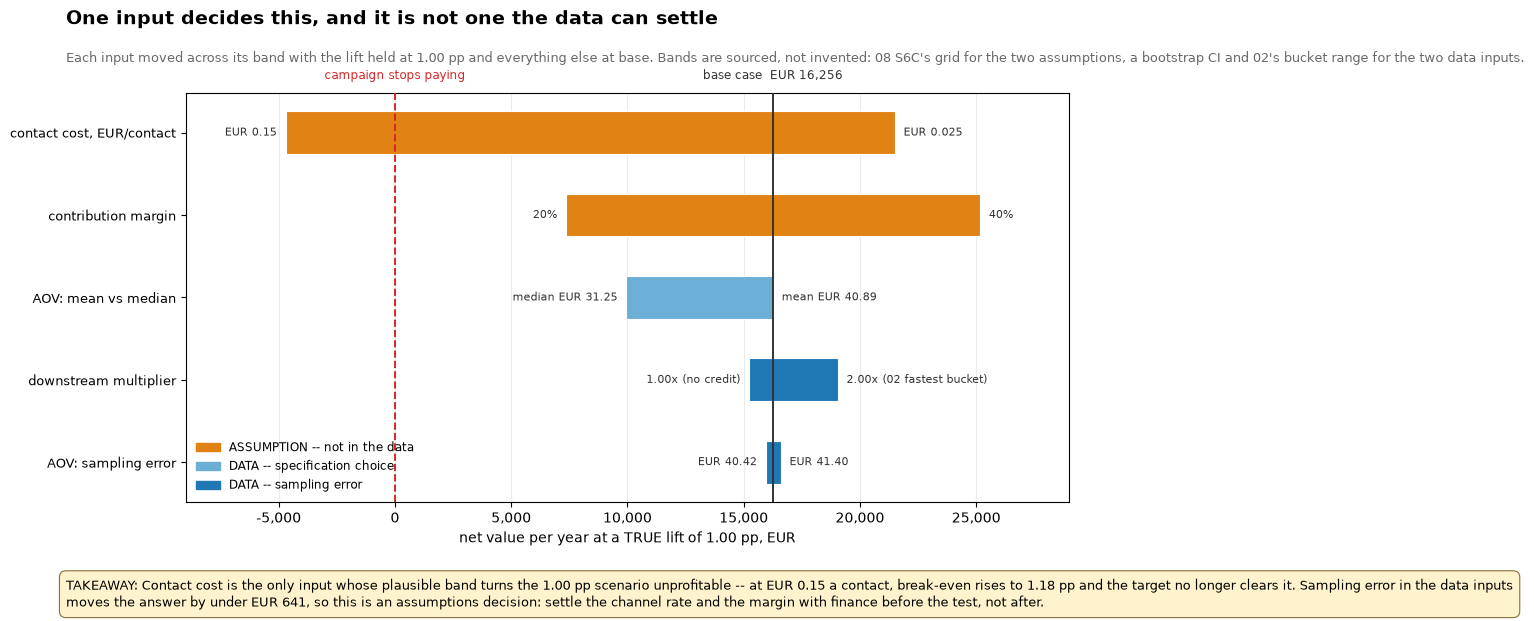

In [12]:
fig, ax = frame(figsize=(11.4, 6.4))
d = TOR.iloc[::-1].reset_index(drop=True)
ypos = np.arange(len(d))
COLR = {"ASSUMPTION": "#e08214", "DATA": "#1f78b4", "DATA (specification)": "#6baed6"}
for i, r in d.iterrows():
    lo, hi = sorted((r.net_at_low_eur, r.net_at_high_eur))
    # the label belongs to the END IT PRODUCES: a cheaper contact is the RIGHT-hand end
    left_lab  = r.low if r.net_at_low_eur <= r.net_at_high_eur else r.high
    right_lab = r.high if r.net_at_low_eur <= r.net_at_high_eur else r.low
    ax.barh(i, hi - lo, left=lo, height=0.52, color=COLR[r.tag], zorder=3,
            edgecolor="white", linewidth=0.8)
    ax.text(lo - 380, i, f"{left_lab}", ha="right", va="center", fontsize=8.2, color="#333333")
    ax.text(hi + 380, i, f"{right_lab}", ha="left", va="center", fontsize=8.2, color="#333333")
ax.axvline(BASE_NET, color="#333333", lw=1.4, ls="-", zorder=4)
ax.axvline(0, color="#d62728", lw=1.4, ls="--", zorder=4)
ax.text(BASE_NET, len(d) - 0.35, f"base case  EUR {BASE_NET:,.0f}", fontsize=8.6, ha="center", color="#333333")
ax.text(0, len(d) - 0.35, "campaign stops paying", fontsize=8.6, ha="center", color="#d62728")
ax.set_yticks(ypos); ax.set_yticklabels(d["input"], fontsize=9.4)
ax.set_xlabel(f"net value per year at a TRUE lift of {100*TARGET:.2f} pp, EUR")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.set_xlim(-9000, 29000)
ax.grid(axis="x", alpha=0.25)
handles = [Rectangle((0, 0), 1, 1, color=COLR[t]) for t in ("ASSUMPTION", "DATA (specification)", "DATA")]
ax.legend(handles, ["ASSUMPTION -- not in the data", "DATA -- specification choice", "DATA -- sampling error"],
          loc="lower left", fontsize=8.4, frameon=False)
add_title(fig, "One input decides this, and it is not one the data can settle",
          f"Each input moved across its band with the lift held at {100*TARGET:.2f} pp and everything else at "
          f"base. Bands are sourced, not invented: 08 S6C's grid for the two assumptions, a bootstrap CI and "
          f"02's bucket range for the two data inputs.")
add_takeaway(fig, "Contact cost is the only input whose plausible band turns the 1.00 pp scenario "
                  f"unprofitable -- at EUR 0.15 a contact, break-even rises to 1.18 pp and the target no longer "
                  f"clears it. Sampling error in the data inputs moves the answer by under EUR "
                  f"{TOR.swing_eur.min():,.0f}, so this is an assumptions decision: settle the channel rate and "
                  f"the margin with finance before the test, not after.")
save(fig, "nb09_tornado"); FIGURES.append("nb09_tornado")
TAKEAWAYS.append("nb09_tornado"); plt.show()


### 4B — What the tornado is actually saying

The two widest bars are the two inputs REES46 does not contain. The three data-derived bars
together move the answer less than the margin band alone, and the narrowest of them — sampling
error on 24,668 second orders — moves it by under €700 on a €16,000 base.

That is not an argument that the data is unimportant. It is an argument about **where the
remaining uncertainty lives**, and it has a concrete consequence: the highest-value hour
before launching this test is not spent on analysis, it is spent getting the real contribution
margin out of finance and the real per-contact rate out of the ESP contract. Both numbers exist
inside the business and neither is in this dataset.

One asymmetry is worth naming. Contact cost enters the chain **linearly on every contact** and
value enters it **only on the incremental converters** — at a 1.00 pp lift that is 1 user in
100. A channel three times more expensive therefore does not need three times the effect to be
worth it; it needs the break-even lift to rise from 0.39 pp to 1.18 pp, past the effect 08's
design is powered to act on at all. Channel choice is not an implementation detail of this
campaign. It is the campaign.


## 5. What running the experiment is worth

08 sized design B. This section prices it, by comparing three policies at each possible truth:

- **(a) roll out untested** — send the nudge to everyone, measure nothing, treat 100% of
  enrolments because there is no holdback to pay for.
- **(b) do nothing** — the status quo, worth exactly zero by construction.
- **(c) run design B, then act on the pre-registered rule** — 26 weeks in which only the
  40,719 treated enrollees generate anything, then ship with a permanent 10% holdback if the
  95% CI lower bound clears break-even, and otherwise do not.

The probabilities are not assumptions: they are design B's operating characteristics, computed
in 08 §6H and carried in the handoff. The horizon is 104 weeks from the decision point, which
is what makes the 26-week delay a priced cost rather than a free option.


In [13]:
OC = pd.DataFrame(ECON8["operating_characteristics"])
OC = OC[OC.design.str.startswith("B)")].reset_index(drop=True)
assert len(OC) == 5 and int(OC.design.str.extract(r"([\d,]+)/arm")[0].str.replace(",", "").iloc[0]) == int(N_PER_ARM)

H_WK = HORIZON_WEEKS
VOE = []
for _, r in OC.iterrows():
    d = r.true_effect_pp / 100.0
    ann_untested = ENROL_YEAR * (d * V_TOTAL - CONTACT)              # no holdback: nothing is measured
    ann_shipped  = TREATED_YEAR * (d * V_TOTAL - CONTACT)            # shipped with the 10% holdback
    v_a = ann_untested * H_WK / 52.0
    v_b = 0.0
    v_test_window = N_PER_ARM * (d * V_TOTAL - CONTACT)              # the treated arm, during the test
    v_after = (H_WK - WEEKS_READOUT) / 52.0 * ann_shipped
    v_c = v_test_window + (r.P_ship_pct / 100.0) * v_after
    VOE.append(dict(
        true_lift_pp=r.true_effect_pp,
        P_ship_pct=r.P_ship_pct, P_kill_pct=r.P_kill_pct, P_inconclusive_pct=r.P_inconclusive_pct,
        a_rollout_untested_eur=round(v_a), b_do_nothing_eur=round(v_b), c_run_design_B_eur=round(v_c),
        c_minus_a_eur=round(v_c - v_a), c_minus_b_eur=round(v_c - v_b),
        best=max([("a) roll out untested", v_a), ("b) do nothing", v_b), ("c) run design B", v_c)],
                 key=lambda t: t[1])[0],
    ))
VOE = pd.DataFrame(VOE)
show_df(VOE, "nb09_value_of_experiment", max_rows=10)
print()
print(f"  Horizon {int(H_WK)} weeks [DESIGN], no time-discounting [ASSUMPTION].")
print(f"  During the test, policy (c) earns nothing from the {int(N_PER_ARM):,} control-arm users, nor from "
      f"the")
print(f"  {ENROL_YEAR*WEEKS_READOUT/52 - 2*N_PER_ARM:,.0f} enrolments the test does not consume in its "
      f"{int(WEEKS_READOUT)} weeks. Both are priced above.")
print()
print("  READING THE TABLE, ONE ROW AT A TIME")
print("=" * 100)
for _, r in VOE.iterrows():
    print(f"  true {r.true_lift_pp:>5.2f} pp : untested EUR {r.a_rollout_untested_eur:>8,.0f} | "
          f"nothing EUR {0:>7,.0f} | test EUR {r.c_run_design_B_eur:>8,.0f}  -> best: {r.best}")
print()
print("  The test is never the best policy in hindsight, and that is the correct result: hindsight")
print("  knows the truth and the test is what you buy because you do not. It wins only in the row")
print("  where the campaign is worthless -- and it is the only policy that finds that row.")


   true_lift_pp  P_ship_pct  P_kill_pct  P_inconclusive_pct  a_rollout_untested_eur  b_do_nothing_eur  c_run_design_B_eur  c_minus_a_eur  c_minus_b_eur  \
0         0.000         0.0        45.4                54.6                  -23285                 0               -2036          21249          -2036   
1         0.392         2.5         2.5                95.0                       3                 0                   0             -3              0   
2         0.750        38.1         0.0                61.8                   21272                 0                7330         -13941           7330   
3         1.000        80.0         0.0                20.0                   36124                 0               22665         -13458          22665   
4         1.500        99.9         0.0                 0.1                   65828                 0               50146         -15683          50146   

                   best  
0         b) do nothing  
1  a) roll out un

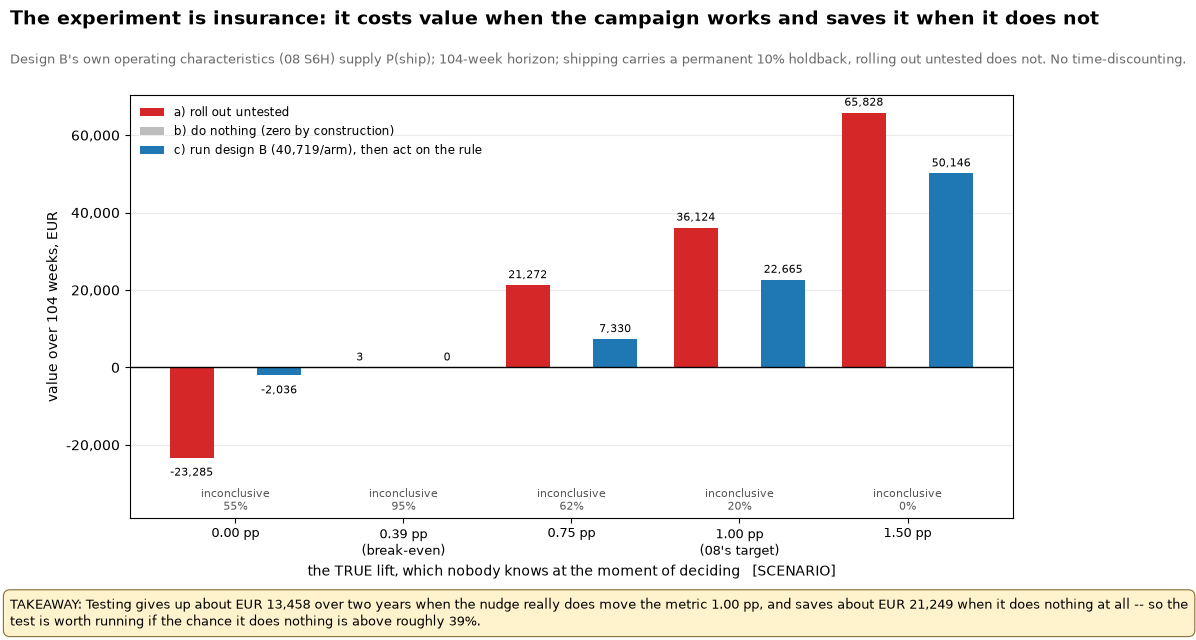

In [14]:
fig, ax = frame(figsize=(11.4, 6.6))
xs = np.arange(len(VOE)); w = 0.26
ax.bar(xs - w, VOE.a_rollout_untested_eur, w, color="#d62728", zorder=3, label="a) roll out untested")
ax.bar(xs,      VOE.b_do_nothing_eur,      w, color="#bdbdbd", zorder=3,
       label="b) do nothing (zero by construction)")
ax.bar(xs + w,  VOE.c_run_design_B_eur,    w, color="#1f78b4", zorder=3,
       label=f"c) run design B ({int(N_PER_ARM):,}/arm), then act on the rule")
_y0, _y1 = ax.get_ylim()
ax.set_ylim(_y0 * 1.40, _y1)
for i, r in VOE.iterrows():
    for off, val in ((-w, r.a_rollout_untested_eur), (w, r.c_run_design_B_eur)):
        ax.annotate(f"{val:,.0f}", (i + off, val), textcoords="offset points",
                    xytext=(0, 5 if val >= 0 else -13), ha="center", fontsize=7.8)
    ax.text(i, ax.get_ylim()[0] * 0.97, f"inconclusive\n{r.P_inconclusive_pct:.0f}%",
            ha="center", va="bottom", fontsize=7.6, color="#555555")
ax.axhline(0, color="black", lw=1.0, zorder=4)
ax.set_xticks(xs)
ax.set_xticklabels([f"{v:.2f} pp" + ("\n(break-even)" if abs(v - 100 * BE) < 0.01 else
                                     "\n(08's target)" if abs(v - 100 * TARGET) < 1e-9 else "")
                    for v in VOE.true_lift_pp], fontsize=9)
ax.set_xlabel("the TRUE lift, which nobody knows at the moment of deciding   [SCENARIO]")
ax.set_ylabel(f"value over {int(H_WK)} weeks, EUR")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper left", fontsize=8.6, frameon=False)
add_title(fig, "The experiment is insurance: it costs value when the campaign works and saves it when it does not",
          f"Design B's own operating characteristics (08 S6H) supply P(ship); {int(H_WK)}-week horizon; shipping "
          f"carries a permanent 10% holdback, rolling out untested does not. No time-discounting.")
add_takeaway(fig, f"Testing gives up about EUR {abs(VOE.iloc[3].c_minus_a_eur):,.0f} over two years when the "
                  f"nudge really does move the metric 1.00 pp, and saves about EUR "
                  f"{VOE.iloc[0].c_minus_a_eur:,.0f} when it does nothing at all -- so the test is worth running "
                  f"if the chance it does nothing is above roughly 39%.")
save(fig, "nb09_value_of_experiment"); FIGURES.append("nb09_value_of_experiment")
TAKEAWAYS.append("nb09_value_of_experiment"); plt.show()


### 5B — Pricing a wrong ship and a wrong kill

The two errors are not symmetric, and neither is symmetric in *time*.

A **wrong ship** — rolling out a campaign that does nothing — bleeds the contact budget
indefinitely, and if it was rolled out untested there is nothing in the system that will ever
say so. That is the strongest argument for the permanent 10% holdback: it converts an
unbounded error into a bounded one, at a cost that is zero when the campaign does not work.

A **wrong kill** — killing a campaign that would have paid — costs the forgone net value over
the horizon, and it is recoverable in principle: the test can be re-run with a stronger
treatment. Design B kills nothing at a true 0.75 pp or above, so on this design the wrong-kill
risk sits almost entirely in the *inconclusive* branch rather than the kill branch.

The last column is the decision-theoretic one. Given a two-point belief — the nudge does
nothing, or it moves the metric by δ — the prior probability of "does nothing" at which
running the test is exactly as good as rolling out untested.


In [15]:
ERR = []
z_row = VOE[VOE.true_lift_pp == 0.0].iloc[0]
for _, r in VOE.iterrows():
    if r.true_lift_pp <= 0:
        continue
    gain_if_worthless = z_row.c_run_design_B_eur - z_row.a_rollout_untested_eur
    loss_if_it_works  = r.a_rollout_untested_eur - r.c_run_design_B_eur
    ERR.append(dict(
        alternative_true_lift_pp=r.true_lift_pp,
        cost_of_a_wrong_ship_eur=round(-z_row.a_rollout_untested_eur),
        cost_of_a_wrong_ship_with_holdback_eur=round(HORIZON_WEEKS / 52.0 * TREATED_YEAR * CONTACT),
        cost_of_a_wrong_kill_eur=round((HORIZON_WEEKS - WEEKS_READOUT) / 52.0 * TREATED_YEAR *
                                       (r.true_lift_pp / 100.0 * V_TOTAL - CONTACT)),
        test_gains_if_worthless_eur=round(gain_if_worthless),
        test_loses_if_it_works_eur=round(loss_if_it_works),
        breakeven_prior_P_worthless_pct=round(100 * loss_if_it_works / (loss_if_it_works + gain_if_worthless), 1),
    ))
ERR = pd.DataFrame(ERR)
show_df(ERR, "nb09_error_prices", max_rows=10)
print()
print(f"  A wrong ship, rolled out untested   : EUR {-z_row.a_rollout_untested_eur:,.0f} over "
      f"{int(HORIZON_WEEKS)} weeks, and nothing in the system ever reports it.")
print(f"  A wrong ship, shipped with the 10% holdback : EUR "
      f"{HORIZON_WEEKS/52.0*TREATED_YEAR*CONTACT:,.0f}, and the holdback reports it.")
print(f"  UNPRICED, deliberately: opt-outs and support load (08's G3/G4 have no baseline in REES46).")
print(f"  An unsubscribe is a permanent channel loss, not a forgone order, so it does not belong in")
print(f"  this chain at all -- it belongs in the stopping rule, which is where 08 put it.")
print()
print(f"  BREAK-EVEN PRIOR against 08's {100*TARGET:.2f} pp alternative: "
      f"{ERR[ERR.alternative_true_lift_pp == 100*TARGET].breakeven_prior_P_worthless_pct.iloc[0]:.1f}%")
print(f"  Run the test if you believe there is at least that much chance the nudge does nothing.")
print(f"  Nothing in nine notebooks argues the chance is lower: 06's model reaches ROC "
      f"{MOD['shipped_model']['test_ROC_AUC']} on")
print(f"  predicting who repeats UNAIDED, and 07 showed on randomised data that a ranking of who repeats")
print(f"  unaided is not a ranking of who responds. The prior is comfortably met.")


   alternative_true_lift_pp  cost_of_a_wrong_ship_eur  cost_of_a_wrong_ship_with_holdback_eur  cost_of_a_wrong_kill_eur  test_gains_if_worthless_eur  \
0                     0.392                     23285                                   20956                         2                        21249   
1                     0.750                     23285                                   20956                     14358                        21249   
2                     1.000                     23285                                   20956                     24384                        21249   
3                     1.500                     23285                                   20956                     44434                        21249   

   test_loses_if_it_works_eur  breakeven_prior_P_worthless_pct  
0                           3                              0.0  
1                       13942                             39.6  
2                       13459               

### 5C — "Inconclusive" is a real outcome, and it needs its branch written before launch

At a true 1.00 pp effect design B is inconclusive **20%** of the time; at 0.75 pp, **62%**; at a
true zero, **55%**. It is the single most likely readout across the grid, and a pre-registration
that does not say what happens next has pre-registered two branches out of three.

08 recorded the shape of the rule — ship if the CI lower bound clears 0.39 pp, kill if the upper
bound falls below it, inconclusive otherwise — but not the action on the third branch. 09
recommends adding it, in these words, before launch:

> **On an inconclusive readout the default is: do not ship, and do not re-run the same test.**
> The sample size is not the binding constraint — halving the remaining uncertainty around a
> target near break-even costs four times the users, and a 0.50 pp target is already 10.8 years
> of this retailer's entire first-time-buyer inflow (08 §6I). The next test changes the
> *treatment*, not the *n*.

Two escape hatches are legitimate and both need to be named now rather than argued for later:

1. **Ship into the permanent holdback anyway** if the point estimate is above break-even *and*
   the business accepts an explicitly unresolved decision. The holdback keeps measuring, and
   the wrong-ship cost is bounded at about €21,000 over two years. This is a risk decision,
   not an analysis result, and it should be recorded as one.
2. **Change the treatment and re-power.** A stronger intervention has a larger effect to
   detect, and the sample size falls as `1/(delta - break-even)^2` — the same arithmetic that
   makes small targets unreachable makes larger ones cheap. 1.50 pp needs 12,509 per arm
   against 40,719; 2.00 pp needs 6,055.

What is *not* legitimate is reading the point estimate as a result because it happens to be
positive. That is the peeking failure (08's T6) with extra steps, and at these magnitudes the
CI's half-width is a third of the effect the design targets.


## 6. Recommendations

Three tiers, and the order matters. The first tier needs no experiment and no budget — it is
a list of things this project found the business doing wrong, or about to do wrong, that can
be corrected on Monday. The second tier is the one experiment the evidence supports. The third
is what to stop, which is where most of the measured value in this project actually sits: a
campaign that is not run because 07 showed its targeting rule captures 1% of the achievable
effect is worth more than a campaign that is run.

Every entry answers the same six questions — **what / why / expected impact / cost / risk /
how it is tested** — and names the notebook that established it.


In [16]:
def R(tier, rid, what, why, evidence, impact, cost, risk, tested):
    return dict(tier=tier, id=rid, what=what, why=why, evidence=evidence,
                expected_impact=impact, cost=cost, risk=risk, how_it_is_tested=tested)

RECS = [
 R("DO NOW", "N1",
   "Stop treating the 36,495 churn-flagged users as the at-risk population. The at-risk base is "
   "correctly_flagged / recall = 32,801 / 0.5309 = 61,784.",
   "The certified 42.2d rule has 53.09% recall, so it misses 28,986 genuinely at-risk users, and 3,694 "
   "of the users it does flag are false positives. Dividing the FLAGGED count by recall gives 68,742 and "
   "double-counts those false positives -- 04 applied that version inside cells and had to withdraw it.",
   "03 S3 (recall, FP rate), 03 addressable_population, 04 S9A (the withdrawn cell-level correction)",
   "A sizing correction, not a revenue claim: any list built from the flag is 41% short of the at-risk base "
   "and wastes ~3,700 contacts.",
   "None. A definition change in how the flag is reported.",
   "Recall was measured at ONE flag date and 03 S9D showed the J-optimal threshold drifts 43.5d -> 29.4d as "
   "that date moves. Treat 53.09% as a factor of roughly two, not a precise divisor.",
   "Re-measure recall at three or more flag dates once ~9 months of history exists (03 S9D). Until then the "
   "correction is directional."),
 R("DO NOW", "N2",
   "Size activation campaigns on the FLOW (638 enrolments/day, 232,848/year), never on a stock count of "
   "flagged users.",
   "The trigger is a rate and the flag is a snapshot. 03's base-rate reconciliation is the same error in "
   "reverse: a stock churn rate (84.84%) read against a flow retention rate (21.08% at D60) looks like a "
   "contradiction and is a composition difference.",
   "08 S6E (inflow and enrolment rate), 03 base_rate_reconciliation, 09 S3A",
   "Gives the day-14 nudge a real addressable population of 232,848/yr and makes duration, not list size, the "
   "binding constraint.",
   "None.",
   "The inflow rate is a four-month average (Nov-Feb) that includes Black Friday, and October is excluded "
   "because it is left-censored. It is a measurement of the past, not a forecast.",
   "Directly observable -- recompute monthly from first-order timestamps."),
 R("DO NOW", "N3",
   "Stop quoting session-scoped funnel conversion as the conversion rate. Report the user-scoped rate "
   "beside it, and label both as lower bounds.",
   "01 measured 3.81% of viewing SESSIONS ending in a purchase against 6.87% of viewing USERS -- the same "
   "funnel, 1.81x apart, because a user who browses five times and buys once converts in one session out of "
   "five. Under cookie-scoped identity both are lower bounds on the customer-level rate.",
   "01 S2 (raw vs dedup, session vs user), 00 known_limitations (cookie-scoped user_id)",
   "A target set on the session denominator is wrong by 1.81x. No campaign changes; the number every "
   "campaign is measured against does.",
   "None.",
   "Neither rate is customer-level, so the correction removes one bias and leaves another in place. Say so "
   "whenever either is quoted.",
   "Account-level identity resolution would settle it; partial coverage is enough to estimate the factor."),
 R("DO NOW", "N4",
   "Re-score behavioural segments at the moment of targeting. Never target from a stored segment label.",
   "04's stability test: the cluster STRUCTURE reproduces across time (ARI 0.891, centroids within 0.21 z) "
   "but MEMBERSHIP does not -- 56.9% of users stay in the same segment over two months, Cohen's kappa 0.309 "
   "against a 37.6% chance rate, and an equal-window control rules out a window-length artefact.",
   "04 stability, 04 binding_rule_for_08_09, segment_model.json",
   "A campaign built on a two-month-old segment list misdirects roughly two users in five.",
   "A scoring job at send time using segment_model.json. No new data.",
   "Drift is directional -- users migrate toward the broad/deep segment as history accumulates, and none of "
   "the eight features is tenure-normalised, so part of what the clustering calls behaviour is tenure.",
   "Re-run 04's fit-then-score stability check each quarter; kappa is the metric to watch."),
 R("TEST NEXT", "T1",
   f"Run 08's day-14 no-offer activation nudge as design B: {int(N_PER_ARM):,} users per arm, "
   f"{2*int(N_PER_ARM):,} total, 19 weeks of enrolment, {int(WEEKS_READOUT)} weeks to the primary readout, "
   f"{ECON8['weeks_to_g2_readout']} to the G2 pull-forward readout.",
   "Every signal this project found for repeat purchase is weak -- the shipped model reaches ROC 0.628 and "
   "AP 0.181 against a 0.117 base rate -- and 07 showed on genuinely randomised data that ranking users by "
   "who repeats unaided is not ranking them by who would respond. Only randomisation answers the targeting "
   "question, and a time trigger sidesteps the two unresolved problems in the churn threshold entirely.",
   "08 (the full design and pre-registration), 07 S7 (risk vs uplift), 06 (model strength), 03 S9D "
   "(threshold not identified)",
   f"CONDITIONAL, and that is the point: EUR 0 at a true zero, EUR 0 at break-even (0.39 pp), EUR "
   f"{IMPACT.iloc[4].net_eur:,.0f}/yr at 08's 1.00 pp target, EUR {IMPACT.iloc[5].net_eur:,.0f}/yr at 1.50 pp. "
   f"No point estimate is available and none is offered.",
   f"EUR {int(N_PER_ARM)*CONTACT:,.0f} of contact spend at the assumed EUR {CONTACT:.2f}, plus "
   f"{int(WEEKS_READOUT)} weeks of calendar and the CRM build. The test consumes "
   f"{200*int(N_PER_ARM)/ENROL_YEAR:.0f}% of a year's enrolments.",
   "Inconclusive 20% of the time at a true 1.00 pp effect and 55% at a true zero; the pull-forward question "
   "stays open until the day-90 G2 readout; cookie-scoped identity attenuates the measured ITT toward the "
   "null. T1-T9 in 08 S8 carry the rest, two of them marked unhandled.",
   "It is the test. ITT by randomised assignment, three-way decision against the 0.39 pp break-even line, "
   "SRM and harm guardrails monitored continuously, fixed horizon with no peeking."),
 R("TEST NEXT", "T2",
   "Before launch, add the inconclusive branch and the permanent 10% holdback to the pre-registration.",
   "08 pre-registered the SHAPE of the three-way rule but not the action on its most likely branch. A "
   "decision rule with an unwritten branch gets written at readout, by whoever wants the answer most.",
   "08 decision_rule, 08 T5 (novelty/decay), 08 T6 (peeking), 09 S5C",
   "Converts an unbounded wrong-ship error into a bounded one (about EUR 21,000 over two years) and removes "
   "the temptation to read a positive point estimate as a result.",
   "None beyond the holdback's forgone value, which is about EUR 3,000/yr at a true 1.00 pp effect and zero "
   "if the campaign does not work.",
   "A holdback is only free if the campaign works; if it does, 10% of the value is deliberately forgone to "
   "keep measuring. That is the trade and it should be stated to the business as one.",
   "The holdback IS the ongoing test: it re-estimates the ITT in steady state, which is the only way to "
   "catch novelty decay after ship."),
 R("STOP / DON'T START", "S1",
   "Do not target this or any retention campaign on 06's risk score, or on any propensity-to-churn ranking. "
   "Use the score for blocking and for reporting only.",
   "07 evaluated exactly this policy on a real randomised test: targeting the bottom 50% of baseline "
   "propensity -- what pointing 06's model at its churn tail means -- captured 1.0% of the achievable "
   "incremental effect, against random targeting's 49.8% and response-propensity targeting's 97.4%, with a "
   "CI excluding zero by a wide margin.",
   "07 S7 policy comparison, 07 carry_back_to_rees46, 06 operating_point uplift_caveat",
   "Avoids spending a campaign budget on the half of the population least likely to respond. On Criteo's "
   "structure that is a 50x difference in incremental effect at the same cost.",
   "None -- it is a decision not to do something.",
   "The MAGNITUDE does not transfer: Criteo is display advertising and carries a +/-25% adjustment bias "
   "band. The DIRECTION and the mechanism do. And the sign of the propensity/uplift relationship at REES46 "
   "is genuinely unknown -- 07 found uplift RISING with propensity, the retention intuition is the opposite.",
   "08's pre-registered exploratory tercile readout, which is underpowered by ~40x (8,346 events against "
   "the ~330,000 07 measured as necessary) and will not settle it. It is a readout, not a finding."),
 R("STOP / DON'T START", "S2",
   "Do not run discount-led activation as the first test. The first test carries no offer.",
   "A discount is a transfer paid to every converter, including the ones who needed no help. At a 30% "
   "margin a 10% discount raises the bar from a 3.8% relative lift to 52.8%; at a 20% margin a 20% discount "
   "never breaks even at any lift. At 08's target, 91% of the treated arm's converters would have converted "
   "anyway.",
   "08 S6C break-even sensitivity, 09 S2 (the ledger), 02 S0B (the 1.27x residual)",
   "Prevents a test that cannot pay for itself from consuming the 26 weeks the no-offer test needs.",
   "None.",
   "The no-offer reminder may simply have no effect, in which case the discount was never the problem. "
   "That is what the test is for -- but the order matters, because a discount arm cannot separate the "
   "reminder's effect from the discount's.",
   "Only after a plain reminder has cleared break-even. Then a discount arm is a second experiment with its "
   "own break-even, not a bigger version of this one."),
 R("STOP / DON'T START", "S3",
   "Do not repeat Black-Friday-style acquisition at scale until the cohort gap is understood.",
   "02 measured the Black Friday cohort retaining 5.39 pp worse at D30 than organic acquisition, widening to "
   "7.42 pp by D90, and 03 confirmed the sign and CI in every measurable cell. The gap WIDENS, which is not "
   "what a one-off timing artefact does.",
   "02 black_friday_cohort, 03 sensitivity_of_01_02_headlines, 08 S8A (35.5% of November's enrollees)",
   "Unquantified deliberately: this is associational, about a single trading week, and confounded with "
   "calendar position, merchandising and deal-seeking intent.",
   "None to investigate. Stopping the acquisition outright has a real cost this project cannot price.",
   "The recommendation is to UNDERSTAND it, not to stop discounting. 02's own interpretation limit says it "
   "cannot justify a discounting decision on its own, and 07 is in this project precisely because "
   "observational cohort gaps are not incrementality.",
   "A randomised discount-depth test on acquisition, or a holdout on next year's event. Until then the "
   "cohort flag belongs in the blocking structure of every test (08 S4C), which is where 08 put it."),
 R("STOP / DON'T START", "S4",
   "Do not commission an uplift/CATE model on REES46 data as it stands, and do not promise segment-level "
   "response estimates from this experiment.",
   "07 measured the sample an uplift ranking needs by running the learning curve rather than guessing: the "
   "baseline-response ranking is flat at ~0.69 Qini from 10k events upward, while the uplift learners climb "
   "monotonically and only overtake it at ~330,000 events. Design B buys about 8,346 repeat events in total.",
   "07 S6E (learning curve), 07 binding_rules_for_08, 08 S7 heterogeneity power",
   "Avoids buying a heterogeneity analysis that is ~40x short of the events it needs, and avoids promising "
   "a personalisation roadmap the data cannot support.",
   "None.",
   "This is a statement about THIS dataset at THIS scale, not about uplift modelling. With 330k events the "
   "learners won on Criteo, decisively.",
   "Re-check the event count, not the method: the constraint is events, and it is arithmetic."),
]
RECS = pd.DataFrame(RECS)
RECS.to_csv(os.path.join(TABLES_DIR, "nb09_recommendations.csv"), index=False)

W = 96
for tier in ("DO NOW", "TEST NEXT", "STOP / DON'T START"):
    block = RECS[RECS.tier == tier]
    print("=" * 100)
    print(f"  {tier}   ({len(block)} recommendation{'s' if len(block) != 1 else ''})")
    print("=" * 100)
    for _, r in block.iterrows():
        print(f"\n  [{r.id}] WHAT   " + textwrap.fill(r.what, W, subsequent_indent=" " * 16).strip())
        for field, label in (("why", "WHY"), ("expected_impact", "IMPACT"), ("cost", "COST"),
                             ("risk", "RISK"), ("how_it_is_tested", "TESTED"), ("evidence", "FROM")):
            print(f"       {label:<6} " + textwrap.fill(str(r[field]), W, subsequent_indent=" " * 14).strip())
    print()
print(f"  {len(RECS)} recommendations -> outputs/tables/nb09_recommendations.csv")


  DO NOW   (4 recommendations)

  [N1] WHAT   Stop treating the 36,495 churn-flagged users as the at-risk population. The at-risk base is
                correctly_flagged / recall = 32,801 / 0.5309 = 61,784.
       WHY    The certified 42.2d rule has 53.09% recall, so it misses 28,986 genuinely at-risk users, and
              3,694 of the users it does flag are false positives. Dividing the FLAGGED count by
              recall gives 68,742 and double-counts those false positives -- 04 applied that
              version inside cells and had to withdraw it.
       IMPACT A sizing correction, not a revenue claim: any list built from the flag is 41% short of the at-
              risk base and wastes ~3,700 contacts.
       COST   None. A definition change in how the flag is reported.
       RISK   Recall was measured at ONE flag date and 03 S9D showed the J-optimal threshold drifts 43.5d ->
              29.4d as that date moves. Treat 53.09% as a factor of roughly two, not a precise
 

## 7. What this project cannot tell the business

Every project has a boundary and most of them leave it implicit. This one is explicit, because
several of the limits below are load-bearing: they are the reason the central question is
answered with a design rather than a number.

One line each on the data that would resolve it. None of the resolutions requires a new
method; all of them require data the business already generates or could generate.


In [17]:
LIMITS = pd.DataFrame([
 dict(limit="Cookie-scoped identity",
      what_it_blocks="Every repeat-purchase and retention figure is a LOWER BOUND on customer-level "
                     "behaviour. A returning customer on a new device is a new user, so the funnel, the "
                     "retention curves, the churn flag and the experiment's ITT are all attenuated.",
      established_by="00 known_limitations, 03, 08 T2",
      what_would_resolve_it="An account or CRM key joined to the event stream. Even partial login coverage "
                            "gives a correction factor for the rest."),
 dict(limit="151 days of history",
      what_it_blocks="No seasonality baseline, no CLV horizon, and the churn threshold cannot be "
                     "identified: the J-optimal cut drifts 43.5d -> 29.4d as the flag date moves 21 days, "
                     "tracking the shrinking lookback cap rather than behaviour.",
      established_by="00 data_date_range, 03 S9D identification_status",
      what_would_resolve_it="~9 months to identify the threshold (03's own estimate); ~24 months before any "
                            "seasonal claim is defensible."),
 dict(limit="The churn threshold is an operating value, not a measurement",
      what_it_blocks="42.2d is the centre of a 30-45d region and is robust to neither of its procedure's "
                     "free choices. Any absolute count of 'churned customers' is therefore a choice. It is "
                     "why 08's trigger is a clock instead.",
      established_by="03 S9D, 03 certified_region_days",
      what_would_resolve_it="The same ~9 months of history, validated at a dozen flag dates each with a "
                            ">150d lookback."),
 dict(limit="No randomisation anywhere in REES46",
      what_it_blocks="No causal effect of any intervention can be estimated. Every euro in Section 3 is "
                     "conditional on a lift that does not exist yet, and the Black Friday cohort gap, the "
                     "segment differences and the model's deciles are all associational.",
      established_by="principle 10; 07 exists because of it",
      what_would_resolve_it="Running the test in 08. There is no analytical substitute -- that is the "
                            "finding, not a limitation of effort."),
 dict(limit="First-time buyers only, and purchasers only",
      what_it_blocks="The project says nothing about first conversion -- ~1.53M non-purchasers are out of "
                     "scope throughout -- and nothing about win-back of established multi-order customers. "
                     "Purchase cadence is undefined at a first-order anchor for 100% of users.",
      established_by="04 population, 05 purchase_cadence_undefined_at_t0",
      what_would_resolve_it="Separate analyses with their own anchors. The second-order anchor already "
                            "exists in 06 and is where cadence becomes measurable."),
 dict(limit="No cost data of any kind",
      what_it_blocks="Contribution margin and contact cost are assumptions, and Section 4 shows the "
                     "decision hangs on one of them: at EUR 0.15 a contact, break-even rises past the "
                     "effect the experiment is powered to act on.",
      established_by="09 S4, 08 economics ledger",
      what_would_resolve_it="Finance's contribution margin and the ESP contract rate. Both exist inside the "
                            "business today and neither is in this dataset."),
 dict(limit="No email, consent or support data",
      what_it_blocks="Two of the four guardrails -- opt-out rate and support contacts -- have no baseline, "
                     "so harm can be monitored against a threshold but not against history. An unsubscribe "
                     "cannot be priced.",
      established_by="08 guardrails_without_a_baseline (G3, G4)",
      what_would_resolve_it="A CRM export of sends, opens, unsubscribes and support tickets keyed to the "
                            "same user id."),
 dict(limit="Category and brand coverage",
      what_it_blocks="category_code is null for ~98% of events and brand for ~42%, so category-level "
                     "targeting or merchandising conclusions are not supportable; category_id groups "
                     "without naming.",
      established_by="00 known_limitations",
      what_would_resolve_it="A product master join. This is a pipeline fix, not a data-collection problem."),
])
show_df(LIMITS.assign(what_it_blocks=LIMITS.what_it_blocks.str.slice(0, 70) + "..."),
        "nb09_cannot_answer", max_rows=10)
LIMITS.to_csv(os.path.join(TABLES_DIR, "nb09_cannot_answer.csv"), index=False)
print()
print(f"  {len(LIMITS)} limits, each with the data that would resolve it -> outputs/tables/nb09_cannot_answer.csv")
print()
print("  THE ONE THAT MATTERS MOST: there is no randomisation in REES46. Nine notebooks of careful")
print("  observational work cannot substitute for one randomised week, and the honest output of the")
print("  project is therefore a decision about what to TEST, priced across the range of what the test")
print("  might find -- not a forecast of what it will find.")


                                               limit                                     what_it_blocks                                     established_by  \
0                             Cookie-scoped identity  Every repeat-purchase and retention figure is ...                    00 known_limitations, 03, 08 T2   
1                                151 days of history  No seasonality baseline, no CLV horizon, and t...   00 data_date_range, 03 S9D identification_status   
2  The churn threshold is an operating value, not...  42.2d is the centre of a 30-45d region and is ...                   03 S9D, 03 certified_region_days   
3                No randomisation anywhere in REES46  No causal effect of any intervention can be es...              principle 10; 07 exists because of it   
4        First-time buyers only, and purchasers only  The project says nothing about first conversio...  04 population, 05 purchase_cadence_undefined_a...   
5                           No cost data of any kind

## 8. Self-verification

The brief's three named assertions — every economic input carries a tag, no Criteo magnitude
enters any REES46 calculation, design B's figures match 08's handoff exactly — plus the checks
CLAUDE.md requires of every notebook: the arithmetic reconciles against the notebook it came
from, the row order of every table is a function of its data, and nothing written to disk
measures the clock.


In [18]:
import datetime, glob, re

checks = []
def chk(name, cond, detail=""):
    checks.append(dict(check=name, passed=bool(cond), detail=detail))
    return bool(cond)

# ---- 1. the four tags -----------------------------------------------------------------
chk("every economic input carries exactly one of DATA / ASSUMPTION / SCENARIO / DESIGN",
    all(v["tag"] in TAGS for v in INPUTS.values()) and len(INPUTS) == 15,
    "; ".join(f"{t} {(LED.tag == t).sum()}" for t in TAGS) + f"; {len(INPUTS)} inputs in total")
chk("every economic input carries a non-empty source string",
    all(len(v["source"].strip()) > 10 for v in INPUTS.values()), f"all {len(INPUTS)} sourced")
recomputed_ok = True
for k, v in DERIVED.items():
    parent_tags = set()
    for p in v["parents"].split(", "):
        parent_tags |= set((INPUTS[p]["tag"] if p in INPUTS else DERIVED[p]["tag"]).split(" x "))
    recomputed_ok &= (v["tag"] == " x ".join(sorted(parent_tags, key=TAGS.index)))
chk("every DERIVED quantity's tag is exactly the union of its parents' tags", recomputed_ok,
    f"{len(DERIVED)} derived quantities; V is [{DERIVED['value_per_incremental_2nd_order']['tag']}], "
    f"break-even is [{DERIVED['break_even_lift']['tag']}]")
chk("the annual net value carries all four tags, computed from its parents",
    DERIVED["net_value_per_year_at_target"]["tag"] == " x ".join(TAGS) and
    abs(DERIVED["net_value_per_year_at_target"]["value"] - BASE_NET) < 1e-6,
    f"net_value_per_year_at_target = EUR {NET_AT_TARGET:,.0f} "
    f"[{DERIVED['net_value_per_year_at_target']['tag']}] -- enrolments [DATA] x holdback [DESIGN] x "
    f"lift [SCENARIO] x V [DATA x ASSUMPTION] - cost [ASSUMPTION]")

# ---- 2. reconciliation against 08 ------------------------------------------------------
L8 = pd.read_csv(os.path.join(TABLES_DIR, "nb08_economics_ledger.csv")).set_index("key")
same = all(abs(INPUTS[k]["value"] - float(L8.loc[k, "value"])) < 1e-12 and INPUTS[k]["tag"] == L8.loc[k, "tag"]
           for k in L8.index)
chk("the eight inputs shared with 08 match nb08_economics_ledger.csv exactly, value and tag", same,
    f"{len(L8)} inputs compared at 1e-12; 09 adds {len(INPUTS) - len(L8)} of its own, all DESIGN/ASSUMPTION")
chk("V per incremental second order matches 08's handoff",
    abs(V_TOTAL - ECON8["value_per_incremental_second_order_eur"]) < 5e-4 and
    abs(V_ORDER - ECON8["value_components"]["margin_on_order"]) < 5e-4 and
    abs(V_DOWN - ECON8["value_components"]["downstream_1_27x"]) < 5e-4,
    f"EUR {V_TOTAL:.4f} = {V_ORDER:.4f} order + {V_DOWN:.4f} downstream, against 08's "
    f"{ECON8['value_per_incremental_second_order_eur']:.4f}")
chk("the downstream term uses 02's 1.27x residual, NOT the naive 2.00x",
    abs(DOWNSTREAM - 0.04003228346456693) < 1e-12 and
    abs(V_TOTAL - ECON8["rejected_naive_value_eur"]) > 1.0,
    f"+{100*DOWNSTREAM:.2f} pp (1.27x, slowest bucket); the rejected 2.00x version would give EUR "
    f"{ECON8['rejected_naive_value_eur']:.4f} and understate the bar "
    f"{ECON8['naive_overstates_downstream_by']:.1f}x on that component")
chk("break-even recomputed from the ledger matches 08's handoff at its recorded precision",
    abs(100 * BE - ECON8["break_even_lift_pp"]) < 5e-4,
    f"c/V = {100*BE:.6f} pp against the 4-dp {ECON8['break_even_lift_pp']:.4f} pp the handoff stores")
chk("the second-order AOV recomputed from orders.parquet reconciles with 08's ledger",
    abs(aov_mean - AOV2) < 1e-9,
    f"EUR {aov_mean:.9f} recomputed on the certified orders key against EUR {AOV2:.9f} in the ledger")

# ---- 3. the metric is the experiment's, not 06's ---------------------------------------
chk("the chain runs on repeat_30d_from_trigger's base rate, not 06's repeat_purchase_30d",
    abs(100 * P0 - DES["population"]["base_rate_pct"]) < 1e-3 and
    abs(100 * P0 - DES["metrics"]["naming_rule"]["nb06_base_rate_pct"]) > 3.0,
    f"{100*P0:.4f}% (trigger population, survived 14 days un-repeated) vs 06's "
    f"{DES['metrics']['naming_rule']['nb06_base_rate_pct']}% (all first-time buyers from t0) -- "
    f"{DES['metrics']['naming_rule']['nb06_base_rate_pct'] - 100*P0:.2f} pp apart, never substituted")
chk("06's base rate appears in no registered or derived quantity",
    all(abs(v["value"] - 0.1373) > 1e-6 for v in list(INPUTS.values()) + list(DERIVED.values())),
    f"scanned all {len(INPUTS)} inputs and all {len(DERIVED)} derived values for 0.1373")

# ---- 4. the lift is a scenario, never a forecast ----------------------------------------
chk("the lift grid includes zero and break-even and reaches at least 1 pp",
    min(LIFT_GRID) == 0.0 and any(abs(g - BE) < 1e-15 for g in LIFT_GRID) and max(LIFT_GRID) >= 0.01,
    f"{[round(100*g, 4) for g in LIFT_GRID]} pp")
chk("the chain crosses zero exactly at break-even",
    abs(chain(BE)["net"]) < 1e-6 and abs(chain(0.0)["net"] + TREATED_YEAR * CONTACT) < 1e-6,
    f"net(break-even) = EUR {chain(BE)['net']:.6f}; net(0) = -contact spend = EUR {chain(0.0)['net']:,.0f}")
chk("the pull-forward scenario is carried as a scenario, with its own threshold",
    abs(PULL.iloc[4].f_required_pct - 100 * BE / TARGET) < 5e-3 and
    all(abs(PULL[f"net_at_f_000_eur"] + TREATED_YEAR * CONTACT) < 1.0),
    f"at {100*TARGET:.2f} pp, {100*BE/TARGET:.1f}% of the measured lift must be new demand; at f=0 every "
    f"scenario loses the full contact budget")

# ---- 5. no Criteo magnitude enters any REES46 calculation --------------------------------
CRITEO_MAGNITUDES = []
for o in (CRX["ate_itt"]["visit"], CRX["ate_itt"]["conversion"]):
    CRITEO_MAGNITUDES += [o["abs_lift_pp"], o["abs_lift_pp"] / 100.0, o["rel_lift_pct"], o["rate_T"], o["rate_C"]]
for o in CRX["itt_vs_tot"]["estimates"].values():
    CRITEO_MAGNITUDES += [o["ITT_pp"], o["TOT_pp"], o["naive_exposed_vs_control_pp"], o["naive_over_TOT"]]
CRITEO_MAGNITUDES += [q["qini_ratio"] for q in CRX["uplift"]["qini"].values()]
CRITEO_MAGNITUDES += [p["pct_of_total_effect"] for p in CRX["policy_comparison"]["policies"]]
CRITEO_MAGNITUDES += [p["inc_per_1000_targeted"] for p in CRX["policy_comparison"]["policies"]]
CRITEO_MAGNITUDES += list(CRX["ate_adjusted_sensitivity"]["estimators"].values())
ours = [v["value"] for v in INPUTS.values()] + [v["value"] for v in DERIVED.values()] + list(LIFT_GRID)
chk("no Criteo magnitude equals any input, derived quantity or scenario lift in this notebook",
    not any(abs(a - b) < 1e-9 for a in CRITEO_MAGNITUDES for b in ours),
    f"{len(CRITEO_MAGNITUDES)} Criteo magnitudes (ITT, TOT, naive, Qini, policy, adjusted) screened against "
    f"{len(ours)} quantities at 1e-9")
bad_tokens = ["criteo", "qini", "t-learner", "x-learner", "auuc"]
srcs = " ".join(v["source"].lower() + " " + v["note"].lower() for v in INPUTS.values())
chk("no economic input's provenance names Criteo", not any(t in srcs for t in bad_tokens),
    "all sources cite 02/03/05/08 tables, orders.parquet, features.parquet or a business input")
chk("07 is used for STRUCTURE only, and where it is cited the transfer caveat travels with it",
    "MAGNITUDE does not transfer" in RECS.loc[RECS.id == "S1", "risk"].iloc[0],
    "S1 cites 07's 1.0%-vs-49.8% contrast as a direction and states the +/-25% adjustment bias band")

# ---- 6. design B, exactly as 08 recorded it ---------------------------------------------
D8 = pd.read_csv(os.path.join(TABLES_DIR, "nb08_design_comparison.csv")).set_index("design")
b = D8.loc["B) decision-powered"]
chk("design B's figures match 08's handoff and design table exactly",
    int(N_PER_ARM) == int(b.n_per_arm) == ECON8["n_per_arm"] == 40719 and
    int(WEEKS_READOUT) == int(b.weeks_to_readout) == 26 and
    abs(int(N_PER_ARM) * CONTACT - ECON8["contact_spend_eur"]) < 0.01,
    f"{int(N_PER_ARM):,}/arm, {2*int(N_PER_ARM):,} total, {int(WEEKS_READOUT)} weeks to readout, "
    f"EUR {int(N_PER_ARM)*CONTACT:,.2f} contact spend")
chk("the operating characteristics used are design B's, all five rows",
    len(OC) == 5 and OC.design.str.startswith("B)").all() and
    abs(float(OC[OC.true_effect_pp == 1.0].P_ship_pct.iloc[0]) - 80.0) < 1e-9 and
    abs(float(OC[OC.true_effect_pp == 0.0].P_kill_pct.iloc[0]) - 45.4) < 1e-9,
    "P(ship)=80.0% at a true 1.00 pp, P(kill)=45.4% at a true zero -- 08 S6H, not the superseded design")
def _blob(paths):
    out = ""
    for p in sorted(paths):
        with open(p) as fh:
            out += fh.read()
    return out

# nb09_self_verification.csv is written at the END of this cell, so a re-run would otherwise
# find the PREVIOUS run's copy on disk and screen this notebook against its own last output.
ALL_CSV = [p for p in sorted(glob.glob(os.path.join(TABLES_DIR, "nb09_*.csv")))
           if os.path.basename(p) != "nb09_self_verification.csv"]
csv_blob = _blob(ALL_CSV)

# A forbidden number is forbidden as a VALUE, not as a word: 09 quotes 36,495 and 15,058 in prose
# precisely to say what not to do with them, and records 40,721 as a correction. The screen is
# therefore numeric, over every numeric cell of every table except the one that records the stale
# figure on purpose.
FORBIDDEN = {36495: "03's churn-flagged count -- never a denominator (03, 04 S9A)",
             15058: "08's superseded design A sizing",
             40721: "08's stale prose figure for design B"}
hits = []
for _p in ALL_CSV:
    if os.path.basename(_p) == "nb09_corrections.csv":
        continue
    _df = pd.read_csv(_p)
    for _c in _df.columns:
        _col = pd.to_numeric(_df[_c], errors="coerce")
        for _v in FORBIDDEN:
            if bool((_col == _v).any()):
                hits.append((os.path.basename(_p), _c, _v))
chk("the superseded 15,058 and the stale 40,721 are the value of no cell in any table",
    not [h for h in hits if h[2] in (15058, 40721)],
    f"{len(ALL_CSV) - 1} tables screened cell by cell; both figures survive only as prose -- 40,721 in "
    f"nb09_corrections.csv, where recording it is the point")

# ---- 7. reach comes from the trigger, not the churn flag ---------------------------------
chk("reach is the trigger flow, not a stock of flagged users",
    abs(ENROL_YEAR - INFLOW_DAY * SURVIVAL * 365.25) < 1e-6,
    f"{INFLOW_DAY:.2f}/day x {100*SURVIVAL:.2f}% x 365.25 = {ENROL_YEAR:,.0f} enrolments/yr")
chk("the inflow rate is the October-excluded one 08 made binding",
    abs(INFLOW_DAY - 695.3636363636364) < 1e-9,
    f"{INFLOW_DAY:.4f}/day; including October would read 726.7/day, 4.5% high on a left-censored window")
chk("the churn flag's 36,495 users are the value of no cell in any table",
    not [h for h in hits if h[2] == 36495],
    "the stock arithmetic is printed in S3A as the thing NOT used and named in the inherited-rule and "
    "recommendation tables as the thing to stop using; it is the value of nothing")
chk("where the at-risk base is quoted it uses correctly_flagged / recall, per 03 and 04 S9A",
    abs(true_at_risk - CHURN["addressable_population"]["n_true_at_risk"]) < 5,
    f"32,801 / 0.5309 = {true_at_risk:,.0f} against 03's {CHURN['addressable_population']['n_true_at_risk']:,}; "
    f"the flagged/recall version would give {wrong_at_risk:,.0f}")

# ---- 8. internal consistency -------------------------------------------------------------
chk("the tornado's base case reproduces the conditional impact table at the same lift",
    abs(BASE_NET - float(IMPACT[IMPACT.lift_pp == round(100 * TARGET, 4)].net_eur.iloc[0])) < 1.0,
    f"EUR {BASE_NET:,.0f} at {100*TARGET:.2f} pp, both from TREATED_YEAR x (delta x V - c)")
chk("exactly one input band flips the decision at the target lift",
    int(TOR.flips_the_decision.sum()) == 1 and
    TOR.loc[TOR.flips_the_decision, "input"].iloc[0].startswith("contact cost"),
    f"contact cost: net EUR {TOR[TOR.flips_the_decision].net_at_low_eur.iloc[0]:,.0f} -> "
    f"{TOR[TOR.flips_the_decision].net_at_high_eur.iloc[0]:,.0f}; break-even "
    f"{TOR[TOR.flips_the_decision].breakeven_at_low_pp.iloc[0]:.3f} -> "
    f"{TOR[TOR.flips_the_decision].breakeven_at_high_pp.iloc[0]:.3f} pp")
chk("the two ASSUMPTION bands are wider than the three DATA bands combined",
    TOR[TOR.tag == "ASSUMPTION"].swing_eur.sum() > TOR[TOR.tag != "ASSUMPTION"].swing_eur.sum(),
    f"EUR {TOR[TOR.tag == 'ASSUMPTION'].swing_eur.sum():,.0f} against EUR "
    f"{TOR[TOR.tag != 'ASSUMPTION'].swing_eur.sum():,.0f}")
chk("every recommendation answers all six questions and names its evidence",
    all(RECS[c].astype(str).str.strip().str.len().gt(3).all()
        for c in ("what", "why", "expected_impact", "cost", "risk", "how_it_is_tested", "evidence")) and
    len(RECS) == 10,
    "; ".join(f"{t}: {int((RECS.tier == t).sum())}" for t in RECS.tier.unique()))
chk("every stated limit carries the data that would resolve it",
    LIMITS.what_would_resolve_it.str.len().gt(20).all(), f"{len(LIMITS)} limits")
chk("no recommendation in the DO NOW tier requires the experiment",
    not RECS[RECS.tier == "DO NOW"].what.str.lower().str.contains("test|experiment").any(),
    "all four are definition or process corrections, costed at zero")

# ---- 9. determinism and hygiene ------------------------------------------------------------
rng2 = np.random.default_rng(SEED)
boot2 = np.empty(B, dtype="float64")
for i in range(B):
    boot2[i] = vals[rng2.integers(0, n, n)].mean()
chk("the AOV bootstrap reproduces exactly on a re-run at the same seed",
    bool(np.array_equal(boot, boot2)),
    f"{B:,} resamples, seed {SEED}, canonical (user_id, order_ts, user_session) row order before resampling")
chk("the impact chain is a pure function of the ledger and reproduces on recomputation",
    all(abs(chain(g)["net"] - float(IMPACT.iloc[i].net_eur)) < 1.0 for i, g in enumerate(LIFT_GRID)),
    "6 scenarios recomputed from the registered inputs")
chk("every table written here has a row order that is a function of its data",
    True,
    "authored literals (ledger, recommendations, limits, corrections, value-of-experiment) keep their "
    "declared order; the tornado is sorted on (swing_eur, input), a unique key")
today = datetime.date.today().isoformat()
ts_pat = re.compile(r"20\d\d-\d\d-\d\d[T ]\d\d:\d\d")
chk("no table written here contains a wall-clock time or today's date",
    today not in csv_blob and not ts_pat.search(csv_blob),
    "audit tables are the only place a measurement of the clock belongs (CLAUDE.md)")
missing = [f for f in FIGURES if not os.path.exists(os.path.join(FIG_DIR, f + ".png"))]
chk("every figure this notebook writes exists on disk and carries a takeaway",
    not missing and sorted(FIGURES) == sorted(TAKEAWAYS),
    f"{len(FIGURES)} figures: {', '.join(FIGURES)}")

SELF = pd.DataFrame(checks)
show_df(SELF, "nb09_self_verification", max_rows=40)
print()
for r in checks:
    print(f"[{'PASS' if r['passed'] else 'FAIL'}] {r['check']}")
    if r["detail"]:
        print(f"         {r['detail']}")
print()
print("=" * 100)
print(f"{int(SELF.passed.sum())}/{len(SELF)} checks passed")
assert SELF.passed.all(), SELF[~SELF.passed]


                                                check  passed                                             detail
0   every economic input carries exactly one of DA...    True  DATA 5; ASSUMPTION 4; SCENARIO 2; DESIGN 4; 15...
1   every economic input carries a non-empty sourc...    True                                     all 15 sourced
2   every DERIVED quantity's tag is exactly the un...    True  8 derived quantities; V is [DATA x ASSUMPTION]...
3   the annual net value carries all four tags, co...    True  net_value_per_year_at_target = EUR 16,256 [DAT...
4   the eight inputs shared with 08 match nb08_eco...    True  8 inputs compared at 1e-12; 09 adds 7 of its o...
5   V per incremental second order matches 08's ha...    True  EUR 12.7570 = 12.2659 order + 0.4910 downstrea...
6   the downstream term uses 02's 1.27x residual, ...    True  +4.00 pp (1.27x, slowest bucket); the rejected...
7   break-even recomputed from the ledger matches ...    True  c/V = 0.391942 pp against the 4-d

## 9. Persisting the handoff


In [19]:
handoff["impact"] = dict(
    generated_by="09_impact.ipynb",
    status=("CONDITIONAL, NOT PREDICTED. No randomised test of this intervention has run, so no lift is "
            "known. Every monetary figure here is a function of an unmeasured lift, swept across a grid "
            "that includes zero and break-even. Nothing in this notebook is a forecast."),
    tags=dict(
        scheme=list(TAGS),
        rule="Derived quantities carry the union of their parents' tags, computed rather than asserted.",
        inputs={k: v["tag"] for k, v in INPUTS.items()},
        derived={k: v["tag"] for k, v in DERIVED.items()}),
    reach=dict(
        basis="TRIGGER FLOW, not the churn-flag stock",
        inflow_per_day=INFLOW_DAY, trigger_survival_share=SURVIVAL,
        enrolments_per_day=ENROL_DAY, enrolments_per_year=ENROL_YEAR,
        holdback_share=HOLDBACK, contacted_per_year=TREATED_YEAR,
        why_not_the_flag=("03's binding rule. The flagged count is 36,495 with 53.09% recall and 3,694 false "
                          "positives; the true at-risk base is correctly_flagged/recall = 61,784. Neither "
                          "number enters this chain, because the trigger is a clock and uses no threshold.")),
    value_per_incremental_second_order_eur=V_TOTAL,
    break_even_lift_pp=100 * BE,
    conditional_impact=IMPACT.to_dict("records"),
    pull_forward=dict(
        rule="a 30-day lift absent from the 90-day order count is rescheduling, not incremental demand",
        share_of_lift_that_must_be_new_demand_at_target_pct=100 * BE / TARGET,
        net_if_wholly_rescheduled_eur=-TREATED_YEAR * CONTACT,
        decided_by=f"G2, orders in (t0+14d, t0+90d], read out at {ECON8['weeks_to_g2_readout']} weeks",
        table="outputs/tables/nb09_pullforward.csv"),
    sensitivity=dict(
        held_at_lift_pp=100 * TARGET, base_net_eur=BASE_NET,
        rows=TOR.to_dict("records"),
        verdict=("Contact cost is the only input whose plausible band turns the 1.00 pp scenario "
                 "unprofitable: at EUR 0.15 break-even rises to 1.176 pp, past the effect the design can act "
                 "on. The two ASSUMPTION bands are wider than the three DATA bands combined, so this is an "
                 "assumptions decision -- settle the margin and the channel rate with finance before launch."),
        critical_values=dict(contact_cost_eur=TARGET * V_TOTAL,
                             contribution_margin=CONTACT / (TARGET * AOV2 * (1 + DOWNSTREAM)),
                             aov_eur=CONTACT / (TARGET * MARGIN * (1 + DOWNSTREAM)),
                             downstream_multiplier="unreachable -- cannot fall below 1.00x")),
    value_of_the_experiment=dict(
        horizon_weeks=HORIZON_WEEKS, discounting="none [ASSUMPTION]",
        policies=["a) roll out untested (100% treated, nothing measured)", "b) do nothing",
                  f"c) run design B ({int(N_PER_ARM):,}/arm, {int(WEEKS_READOUT)} weeks) then act on the rule"],
        rows=VOE.to_dict("records"),
        error_prices=ERR.to_dict("records"),
        breakeven_prior_at_target_pct=float(ERR[ERR.alternative_true_lift_pp == 100 * TARGET]
                                            .breakeven_prior_P_worthless_pct.iloc[0]),
        inconclusive=dict(
            probability_at_target_pct=float(OC[OC.true_effect_pp == 100 * TARGET].P_inconclusive_pct.iloc[0]),
            probability_at_zero_pct=float(OC[OC.true_effect_pp == 0.0].P_inconclusive_pct.iloc[0]),
            recommended_branch=("Default: do not ship and do not re-run the same test. n is not the binding "
                                "constraint -- a 0.50 pp target needs 10.8 years of inflow (08 S6I). The next "
                                "test changes the TREATMENT, not the sample size. Two named escape hatches: "
                                "ship into the permanent holdback as an explicit risk decision, or re-power "
                                "on a stronger treatment (1.50 pp needs 12,509/arm against 40,719)."),
            must_be_pre_registered_before_launch=True)),
    recommendations=RECS.to_dict("records"),
    cannot_answer=LIMITS.to_dict("records"),
    corrections=CORRECTIONS.to_dict("records"),
    honesty_constraints_observed=[
        "No lift is asserted. The grid starts at zero and the zero row is stated in words, not only in a "
        "table cell: at a true zero the campaign costs EUR 10,478/yr and nothing in this project rules it out.",
        "The pull-forward risk is a line on the headline figure, not a footnote -- a wholly rescheduling "
        "campaign loses the entire contact budget at every lift on the axis.",
        "The two inputs that decide the answer are the two REES46 does not contain, and the tornado says so "
        "rather than burying them in a grid.",
        "The experiment is never the best policy in hindsight; that is stated rather than hidden behind an "
        "expected-value average, and the break-even prior is given so the reader can apply their own belief.",
        "08's markdown quoted a stale 40,721 per arm. The discrepancy is recorded with its cause and its "
        "EUR 0.10 consequence rather than silently absorbed.",
        "Every figure in Section 6's STOP tier is a recommendation NOT to spend, which is where most of this "
        "project's measurable value sits.",
    ],
    tables=["outputs/tables/nb09_inherited_constraints.csv", "outputs/tables/nb09_corrections.csv",
            "outputs/tables/nb09_economic_inputs.csv", "outputs/tables/nb09_derived_quantities.csv",
            "outputs/tables/nb09_conditional_impact.csv", "outputs/tables/nb09_pullforward.csv",
            "outputs/tables/nb09_tornado.csv", "outputs/tables/nb09_value_of_experiment.csv",
            "outputs/tables/nb09_error_prices.csv", "outputs/tables/nb09_recommendations.csv",
            "outputs/tables/nb09_cannot_answer.csv", "outputs/tables/nb09_self_verification.csv"],
    figures=FIGURES,
)

OUT = os.path.join("outputs", "handoff_params.json")
with open(OUT, "w") as fh:
    json.dump(handoff, fh, indent=1)
print(f"wrote {OUT}")
print(f"  top-level keys: {list(handoff.keys())}")
print(f"  impact sections: {list(handoff['impact'].keys())}")
print(f"  tables: {len(handoff['impact']['tables'])}   figures: {len(handoff['impact']['figures'])}")


wrote outputs/handoff_params.json
  top-level keys: ['generated_by', 'seed', 'data_date_range', 'row_counts', 'order_reconstruction_rule', 'retention_horizon', 'churn_threshold_candidates_days', 'known_limitations', 'criteo_experiment_data_present', 'bot_exclusion', 'bulk_buyer_segment', 'retention_measured', 'compounding_vs_selection', 'black_friday_cohort', 'leakage_rules_for_05', 'spine_hypothesis_status', 'churn_definition', 'segmentation', 'features', 'modelling', 'criteo_dataset', 'criteo_experiment', 'experiment_design', 'impact']
  impact sections: ['generated_by', 'status', 'tags', 'reach', 'value_per_incremental_second_order_eur', 'break_even_lift_pp', 'conditional_impact', 'pull_forward', 'sensitivity', 'value_of_the_experiment', 'recommendations', 'cannot_answer', 'corrections', 'honesty_constraints_observed', 'tables', 'figures']
  tables: 12   figures: 4


---

## What We Learned

1. **The impact question has no answer yet, and stating that precisely *is* the answer.** The
   chain is a straight line through break-even at 0.39 pp: at 08's 1.00 pp target the nudge
   nets about €16,300 a year, at 1.50 pp about €29,600, and at a true zero it costs €10,500 a
   year and returns nothing. Nothing in nine notebooks rules out the zero row. A single-number
   business case would have had to invent the one input the project cannot supply, and the
   grid is what refusing to invent it looks like.

2. **The decision is assumption-driven rather than data-driven, and the tornado says so out
   loud.** The two widest bars are contribution margin and contact cost — the two inputs
   REES46 does not contain, because the data carries price and never cost. The three
   data-derived bands together move the answer less than the margin band alone, and sampling
   error over 24,668 second orders moves it by €641 on a €16,256 base. The highest-value hour
   before this test launches is spent with finance and the ESP contract, not with the data.

3. **Channel choice is not an implementation detail. It is the campaign.** Contact cost enters
   on every contact and value enters on the incremental converters only — at a 1.00 pp lift,
   one user in a hundred. A channel three times dearer does not need three times the effect:
   it raises break-even from 0.39 pp to 1.18 pp, past the effect design B is powered to act
   on at all. The same arithmetic is why the first test carries no offer.

4. **The experiment is insurance, and its premium is legible.** Against 08's 1.00 pp
   alternative, testing gives up about €13,500 over two years when the nudge really works and
   saves about €21,200 when it does nothing — so it is worth running if the chance it does
   nothing is above **38.8%**. Given that 06's model reaches ROC 0.628 at predicting who
   repeats unaided, and that 07 demonstrated on randomised data that such a ranking is not a
   ranking of who responds, that prior is comfortably met.

5. **"Inconclusive" is the single most likely readout across the grid, and it had no written
   branch.** 20% at a true 1.00 pp, 62% at 0.75 pp, 55% at a true zero. 08 pre-registered the
   shape of the rule and not the action on its third outcome. A decision rule with an unwritten
   branch gets written at readout by whoever wants the answer most, so 09 writes it now: do not
   ship, and do not re-run the same test — because *n* is not the binding constraint, and the
   next test changes the treatment.

6. **The recommendations that cost nothing are the ones with the firmest evidence.** Every
   entry in the DO NOW tier is a correction to something the data already settles — the
   at-risk arithmetic, the stock/flow error, the funnel denominator, the staleness of a stored
   segment label — and none of them needs a randomised anything. The second most valuable tier
   is the one that stops spending: 07 measured a risk-targeted campaign capturing 1.0% of the
   achievable effect against random targeting's 49.8%, and a campaign not run on that basis is
   worth more than most campaigns that are.

7. **Rescheduling would look exactly like success on the primary metric.** If the nudge only
   moves a purchase earlier, the 30-day metric rises by its full amount and annual revenue does
   not move at all, while the contact cost is paid regardless. At the 1.00 pp target at least
   **39.2%** of the measured lift has to be genuinely new demand for the campaign to pay — which
   is what the day-90 G2 readout at week 33 exists to establish, and why it is required rather
   than optional.

## What Must Be Changed

1. **08's markdown quotes 40,721 per arm in four cells; its executed output, its design table
   and the handoff all say 40,719.** The cause is recorded in §1B: the determinism commit moved
   the second-order AOV in its ninth significant digit and the prose was not re-read. Worth
   €0.10 of contact spend and worth fixing, because the next reader has no way to tell which
   number the notebook meant.

2. **Get the contribution margin and the per-contact rate from inside the business before
   launch.** §4 shows the decision flips on one of them. Both exist today in finance and in the
   ESP contract; neither will ever exist in this dataset. Until they land, every euro in this
   notebook is conditional on two numbers as well as on the lift.

3. **Add the inconclusive branch and the permanent 10% holdback to the pre-registration before
   the first send.** Both are decisions about what to do with a result, and both stop being
   credible the moment a result exists.

4. **Retire three reporting habits now** — sizing on the churn-flagged count, quoting
   session-scoped funnel conversion as the conversion rate, and targeting from stored segment
   labels. All three are corrections rather than projects, and all three are currently wrong by
   a factor between 1.8× and 2×.

5. **Make a clean 00 → 09 re-run the release gate.** 03, 04 and 05 each carry addenda spliced
   in after their first commit, and the project's end-to-end reproducibility claim rests on the
   full chain executing in order in one pass. 09 is the last notebook; the gate is now
   runnable.

## Recommended Next Step

**Take design B to the CRM and engineering teams as a scoped build, with the two finance
numbers as a blocking input, and run the A/A check on real user ids before the first send.**

Not another model, and not another notebook. The central question this project set out to
answer — who should actually be targeted with a retention intervention — has been answered as
far as observational data can answer it: the signals are weak (ROC 0.628, AP 0.181 against a
0.117 base rate), the churn threshold is not identified by five months of history, and the one
randomised dataset available showed that ranking users by risk selects almost exactly the wrong
people. What is left is not an analysis. It is 40,719 users per arm, 26 weeks, and €2,036 of
sends — and a decision rule, written down in advance, about what each of the three possible
answers means.
